# FAMD - canines dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## canines dataset

In [2]:
# canines dataset
from scientisttools.datasets import canines
canines._fields

('actif', 'ind_sup', 'sup_var', 'data')

In [3]:
# overall dataset
data = canines.data
data.info()

<class 'pandas.DataFrame'>
Index: 33 entries, Beauceron to Wisky
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Taille        33 non-null     str    
 1   Poids         33 non-null     str    
 2   Velocite      33 non-null     str    
 3   Intelligence  33 non-null     str    
 4   Affection     33 non-null     str    
 5   Agressivite   33 non-null     str    
 6   Fonction      27 non-null     str    
 7   Cote          27 non-null     float64
dtypes: float64(1), str(7)
memory usage: 2.3+ KB


## Instanciation and training

In [4]:
# instanciation
from scientisttools import FAMD
clf = FAMD(ind_sup=range(27,33),sup_var=(6,7))

### `fit` function

In [5]:
# fit function
clf.fit(data)

,ind_sup,"range(27, 33)"
,sup_var,"(6, ...)"
,group,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,tol,1e-07
Name,Type,Value
call_,call,"call(Xtot= ...ion', 'Cote'])"
eig_,DataFrame,Eigenv... 100.000000


### `fit_transform` function

In [6]:
# fit_transform function - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Beauceron,-0.776978,-1.023155,-0.248544,-0.517911,-0.290288
Basset,0.622439,2.697444,-0.467120,0.716812,-1.283553
Berger All,-1.191421,-1.137664,-1.220174,1.414397,0.675819
Boxer,1.095816,-2.159906,1.695086,0.636872,-1.115963
Bull-Dog,2.482196,1.346924,-0.400303,-0.857124,0.810258
Bull-Mastif,-1.843424,1.339655,1.218800,1.604790,1.768400
Caniche,2.234673,-0.039652,-1.412302,1.538606,1.063119
Chihuahua,2.059529,2.067007,-1.151131,-0.211496,-0.434408
Cocker,1.796199,0.193689,1.622127,0.464774,-0.256283
Colley,-0.287387,-1.288695,-0.820319,-1.611163,0.470621


### `transform` function

In [7]:
# transform function - individuals coordinates
ind_coord = clf.transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Beauceron,-0.776978,-1.023155,-0.248544,-0.517911,-0.290288
Basset,0.622439,2.697444,-0.467120,0.716812,-1.283553
Berger All,-1.191421,-1.137664,-1.220174,1.414397,0.675819
Boxer,1.095816,-2.159906,1.695086,0.636872,-1.115963
Bull-Dog,2.482196,1.346924,-0.400303,-0.857124,0.810258
Bull-Mastif,-1.843424,1.339655,1.218800,1.604790,1.768400
Caniche,2.234673,-0.039652,-1.412302,1.538606,1.063119
Chihuahua,2.059529,2.067007,-1.151131,-0.211496,-0.434408
Cocker,1.796199,0.193689,1.622127,0.464774,-0.256283
Colley,-0.287387,-1.288695,-0.820319,-1.611163,0.470621


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Factor Analysis of Mixed Data (FAMD)**

*The results are available in the following objects:

name              description
----------------  -----------------------------------------------------
.call_            summary called parameters
.eig_             eigenvalues
.ind_             results for the individuals
.ind_sup_         results for the supplementary individuals
.levels_          results for the levels
.levels_sup_      results for the supplementary levels
.quali_var_       results for the qualitative variables
.quali_var_sup_   results for the supplementary qualitative variables
.quanti_var_sup_  results for the supplementary quantitative variables
.svd_             results for generalized singular values decomposition



## Eigen values

In [9]:
#eigenvalues
from scientisttools import get_eig
eig =  get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,2.889637,0.581213,28.896370,28.896370
Dim2,2.308424,1.042699,23.084237,51.980607
Dim3,1.265724,0.320400,12.657243,64.637850
Dim4,0.945324,0.044528,9.453242,74.091092
Dim5,0.900796,0.161024,9.007960,83.099052
Dim6,0.739772,0.250997,7.397718,90.496770
Dim7,0.488775,0.214756,4.887748,95.384518
Dim8,0.274019,0.132767,2.740185,98.124703
Dim9,0.141251,0.094973,1.412515,99.537218
Dim10,0.046278,NaN,0.462782,100.000000


The principal component of the function  `FAMD` must be divide by $\sqrt{J}$ where $J$ is the number of categorical variables. In other words, the eigenvalues should be divide by $J$ to get the identical results with `MCA`.

In [10]:
# eigen values - MCA
J = clf.quali_var_.coord.shape[0]
eig.loc[:,["Eigenvalue"]]/J

,Eigenvalue
Dim1,0.481606
Dim2,0.384737
Dim3,0.210954
Dim4,0.157554
Dim5,0.150133
Dim6,0.123295
Dim7,0.081462
Dim8,0.045670
Dim9,0.023542
Dim10,0.007713


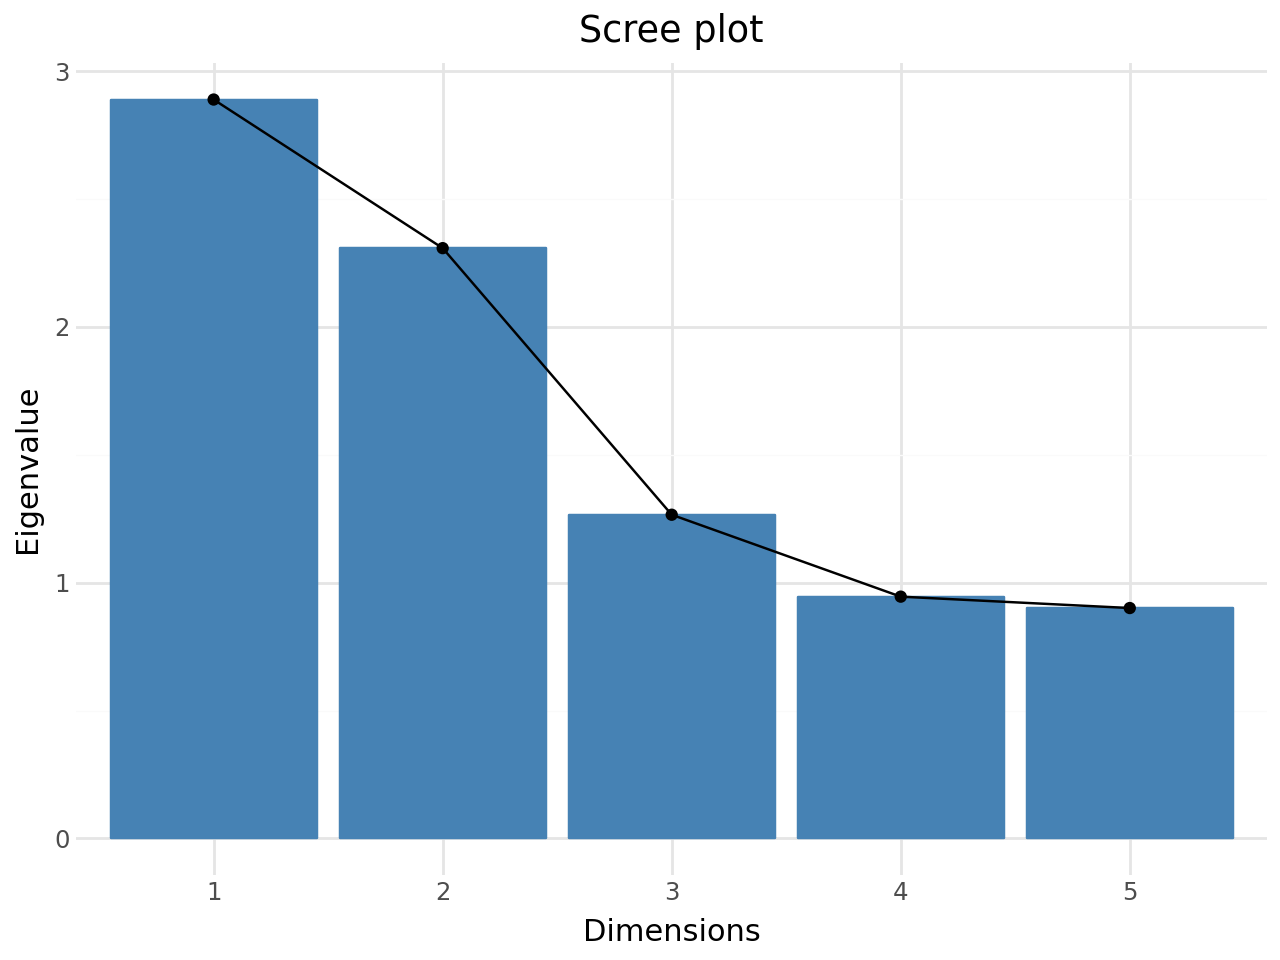

None


In [11]:
# scree plot - eigenvalue
from scientisttools import fviz_screeplot
p = fviz_screeplot(obj=clf,choice="eigenvalue")
print(p.show())

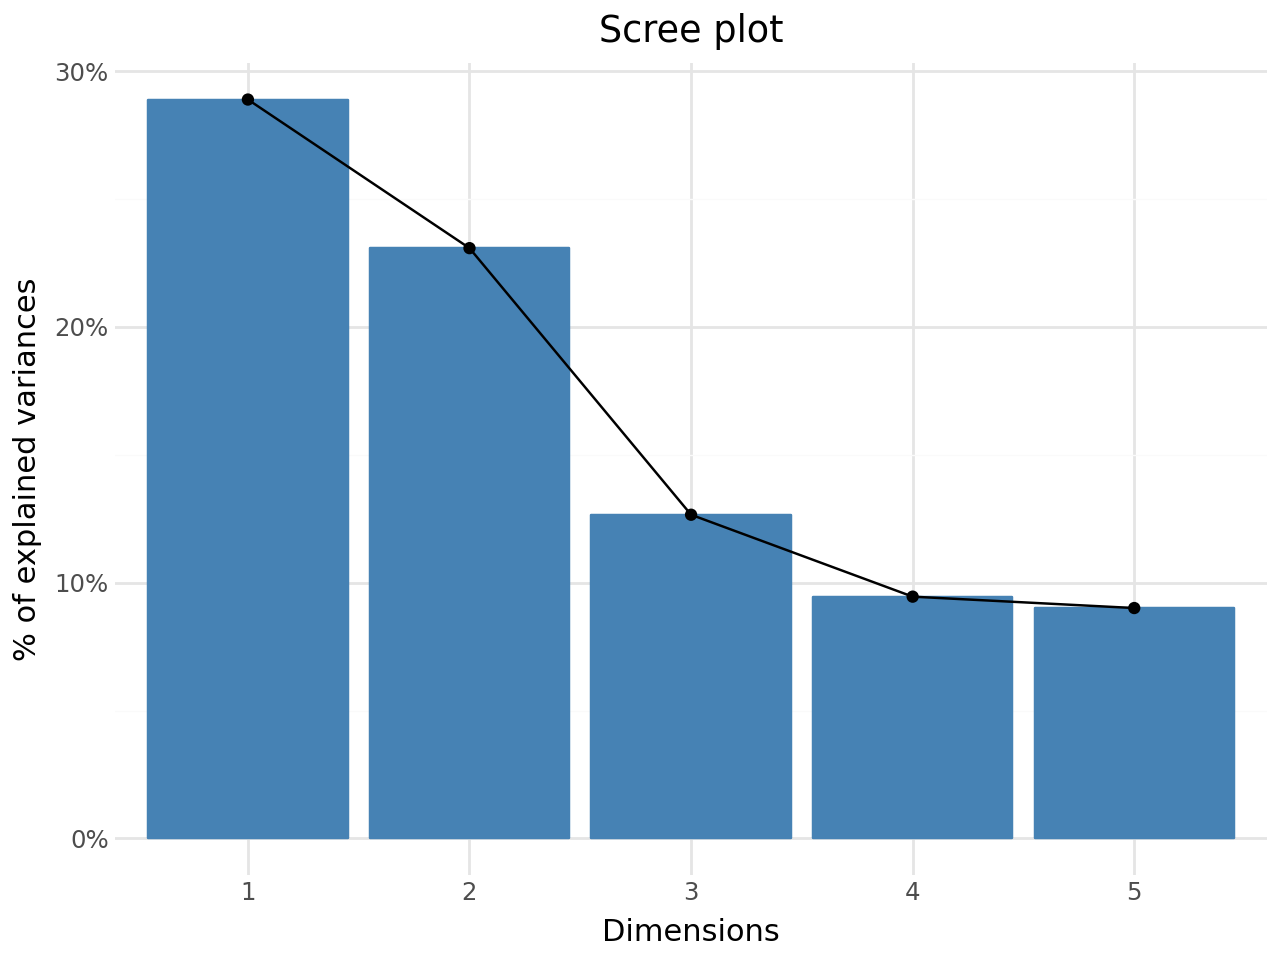

None


In [12]:
# scree plot - proportion
p = fviz_screeplot(obj=clf,choice="proportion")
print(p.show())

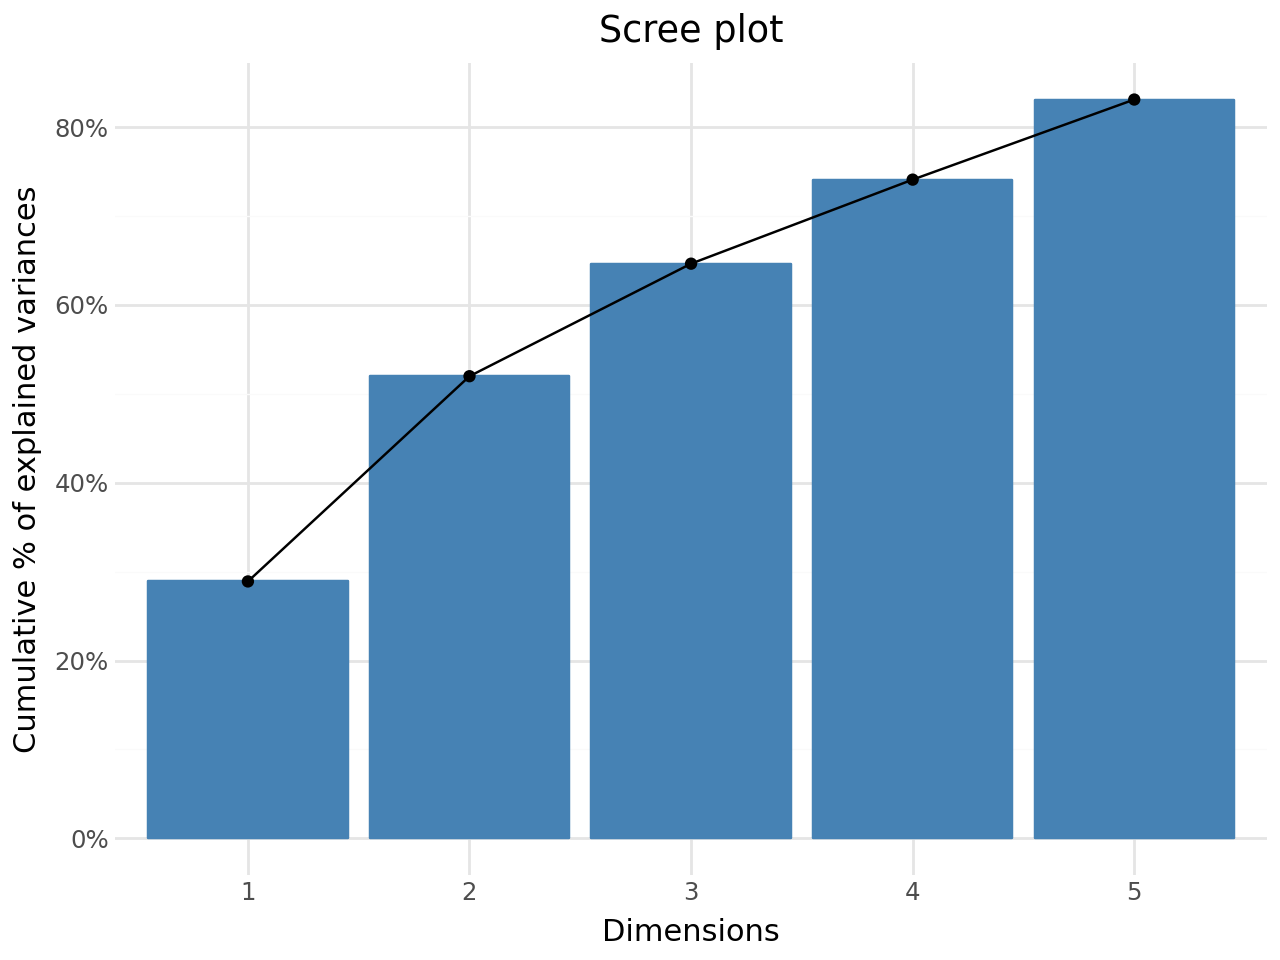

None


In [13]:
# scree plot - cumulative
p = fviz_screeplot(obj=clf,choice="cumulative")
print(p.show())

## Individuals informations

In [14]:
#individuals informations
from scientisttools import get_mix
ind = get_mix(clf)
ind._fields

('coord', 'cos2', 'contrib', 'infos')

### Individuals coordinates

In [15]:
# individuals coordinates
ind.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Beauceron,-0.776978,-1.023155,-0.248544,-0.517911,-0.290288
Basset,0.622439,2.697444,-0.467120,0.716812,-1.283553
Berger All,-1.191421,-1.137664,-1.220174,1.414397,0.675819
Boxer,1.095816,-2.159906,1.695086,0.636872,-1.115963
Bull-Dog,2.482196,1.346924,-0.400303,-0.857124,0.810258
Bull-Mastif,-1.843424,1.339655,1.218800,1.604790,1.768400
Caniche,2.234673,-0.039652,-1.412302,1.538606,1.063119
Chihuahua,2.059529,2.067007,-1.151131,-0.211496,-0.434408
Cocker,1.796199,0.193689,1.622127,0.464774,-0.256283
Colley,-0.287387,-1.288695,-0.820319,-1.611163,0.470621


10 [-0.4136099  -0.91815357]
18 [-0.90930879 -0.21350995]
7 [ 0.85053972 -0.98282909]
21 [0.11603155 0.8644834 ]


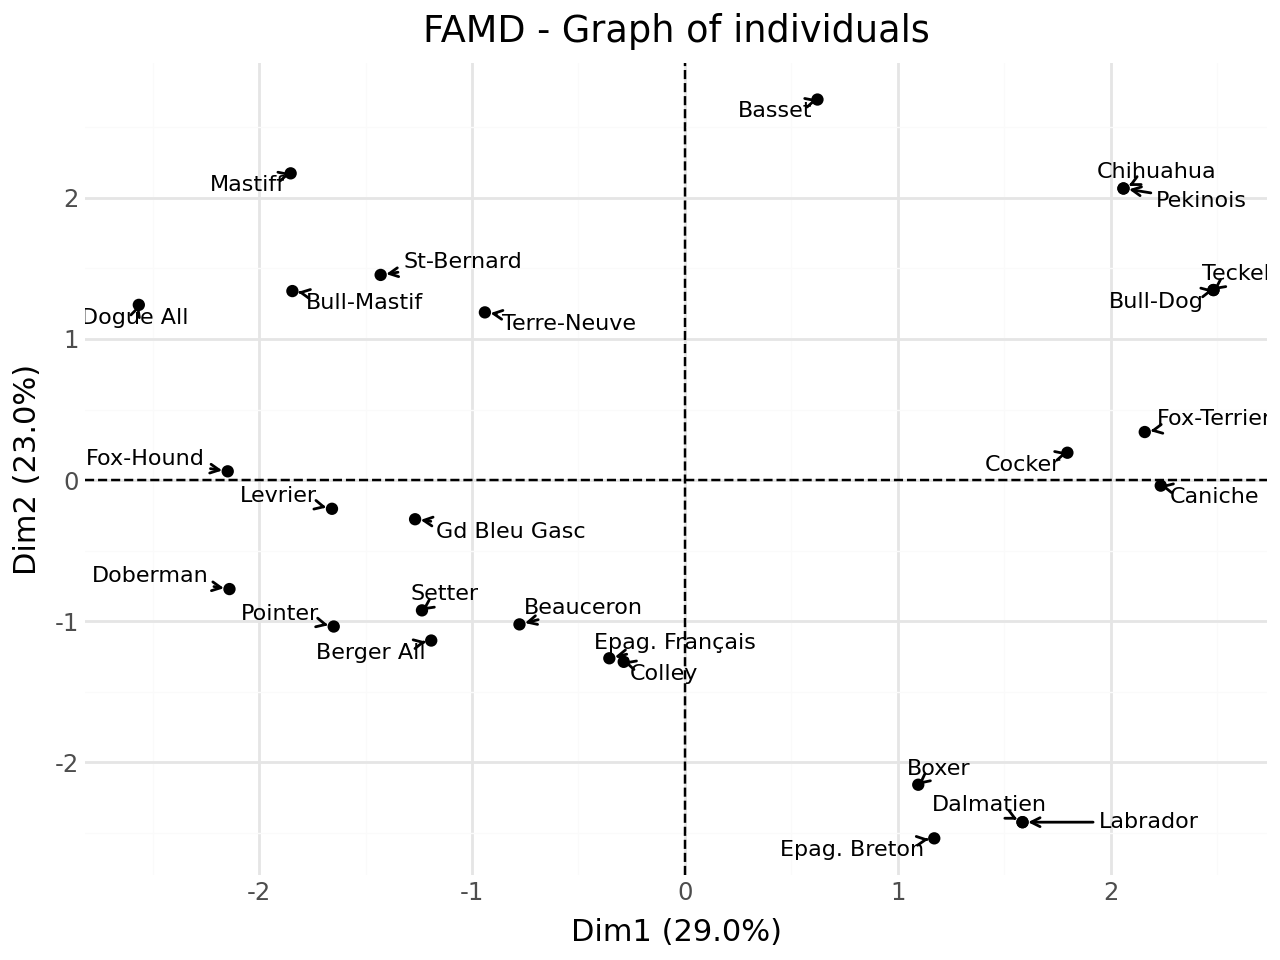

None


In [16]:
# graph of individuals
from scientisttools import fviz_mix
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = False
)
print(p.show())

### Individuals contributions

In [17]:
# individuals contributions
ind.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Beauceron,0.773768,1.679591,0.180761,1.050911,0.346472
Basset,0.496578,11.674160,0.638490,2.013103,6.773884
Berger All,1.819380,2.076582,4.356528,7.837874,1.877893
Boxer,1.539104,7.484976,8.407762,1.589130,5.120461
Bull-Dog,7.897052,2.910764,0.468895,2.878342,2.699333
Bull-Mastif,4.355552,2.879430,4.346724,10.090014,12.857925
Caniche,6.400604,0.002523,5.836494,9.274927,4.647010
Chihuahua,5.436620,6.854956,3.877452,0.175251,0.775901
Cocker,4.135252,0.060191,7.699573,0.846329,0.270054
Colley,0.105859,2.664534,1.969076,10.170316,0.910652


10 [-0.67908784 -0.09684366]
18 [-0.16055656  0.36660497]
7 [-0.14060099  0.33947633]
21 [ 0.72473832 -0.31682475]


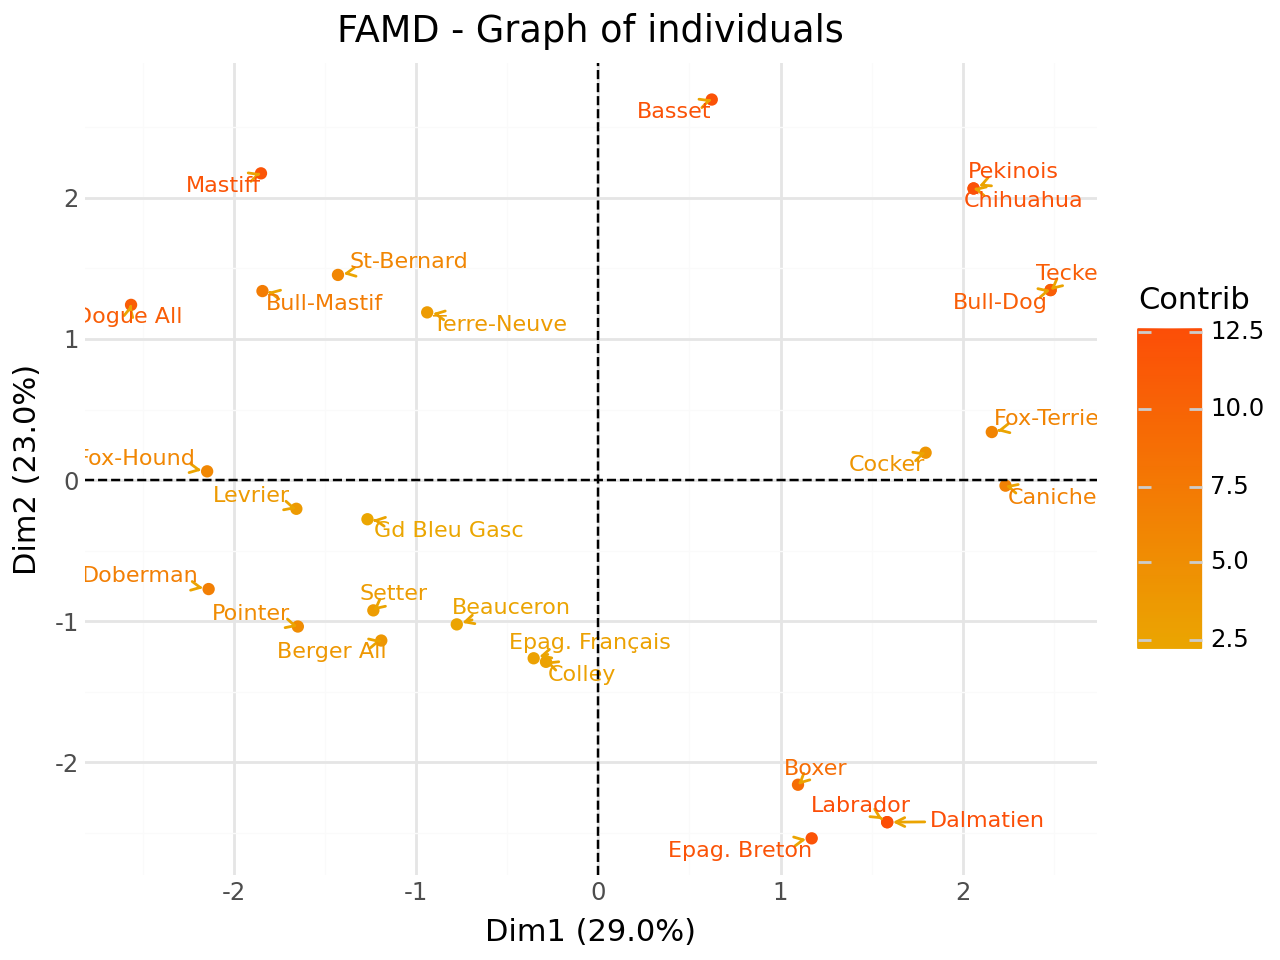

None


In [18]:
# graph of individuals - color by contributions
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind="contrib",
    repel=True,
    ind_sup=False
)
print(p.show())

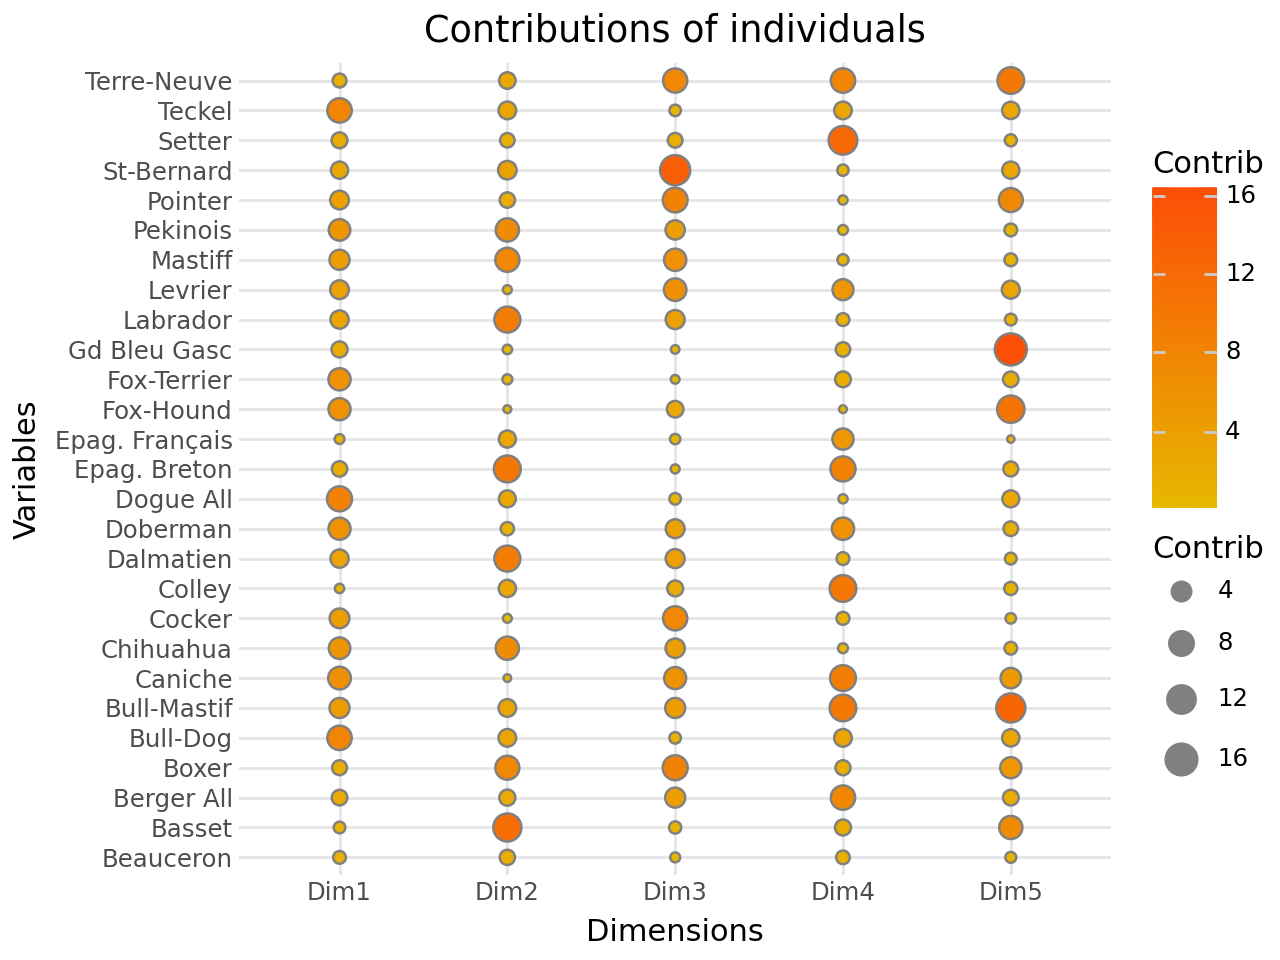

None


In [19]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

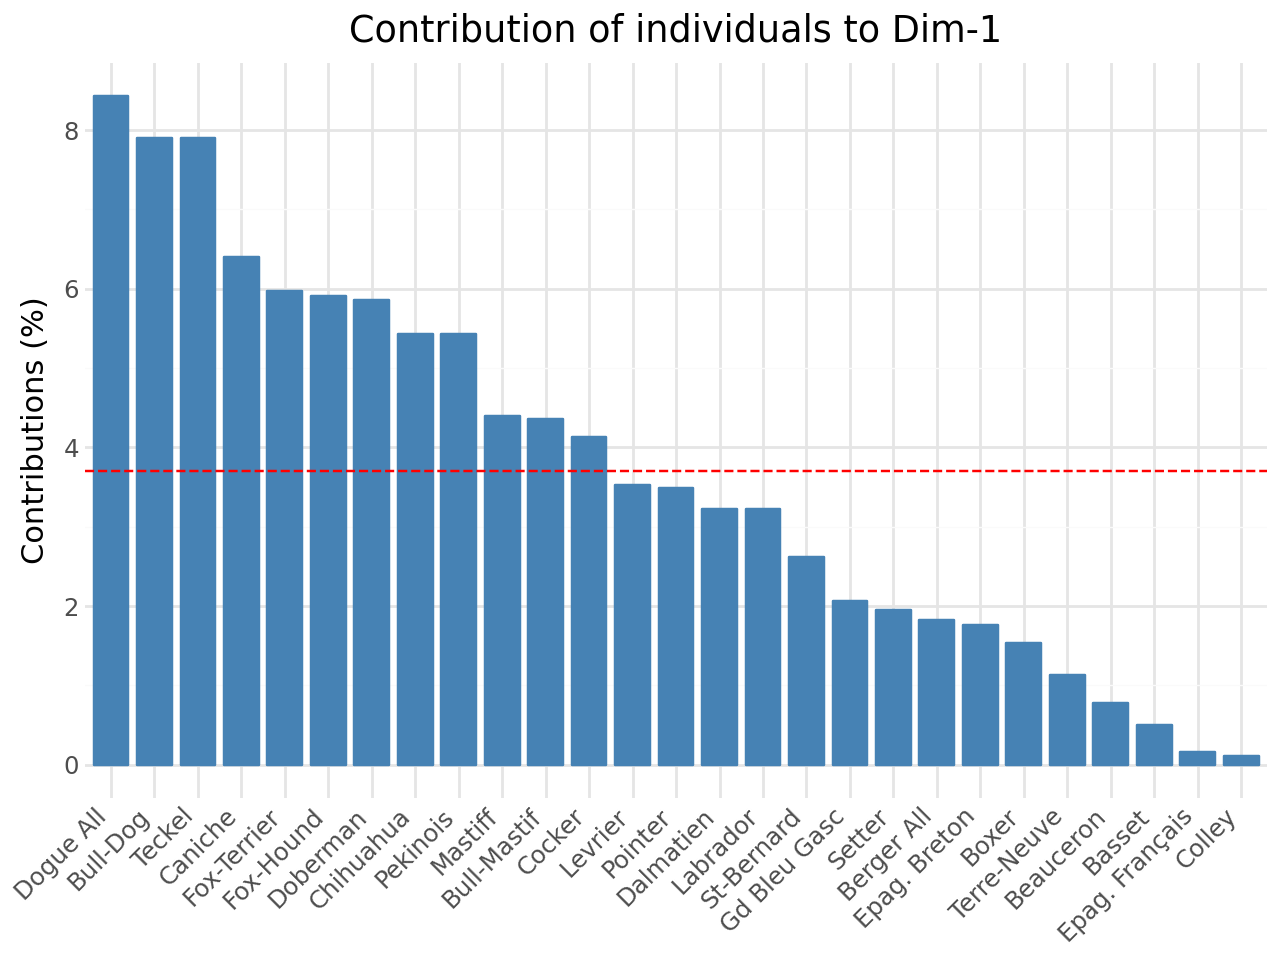

None


In [20]:
# contributions of individuals to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals cos2

In [21]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Beauceron,0.088635,0.153700,0.009070,0.039382,1.237222e-02
Basset,0.033804,0.634867,0.019039,0.044832,1.437493e-01
Berger All,0.153722,0.140164,0.161232,0.216646,4.946160e-02
Boxer,0.111331,0.432524,0.266393,0.037605,1.154621e-01
Bull-Dog,0.624485,0.183881,0.016242,0.074462,6.654209e-02
Bull-Mastif,0.270691,0.142958,0.118328,0.205144,2.491061e-01
Caniche,0.385194,0.000121,0.153853,0.182602,8.717967e-02
Chihuahua,0.379931,0.382695,0.118691,0.004007,1.690306e-02
Cocker,0.279157,0.003246,0.227672,0.018691,5.683030e-03
Colley,0.012396,0.249261,0.100999,0.389612,3.324270e-02


10 [-0.24405996 -0.94915435]
18 [-0.30921124 -0.19491315]
7 [-0.57069779  0.71242742]
21 [ 0.57932911 -0.34723306]


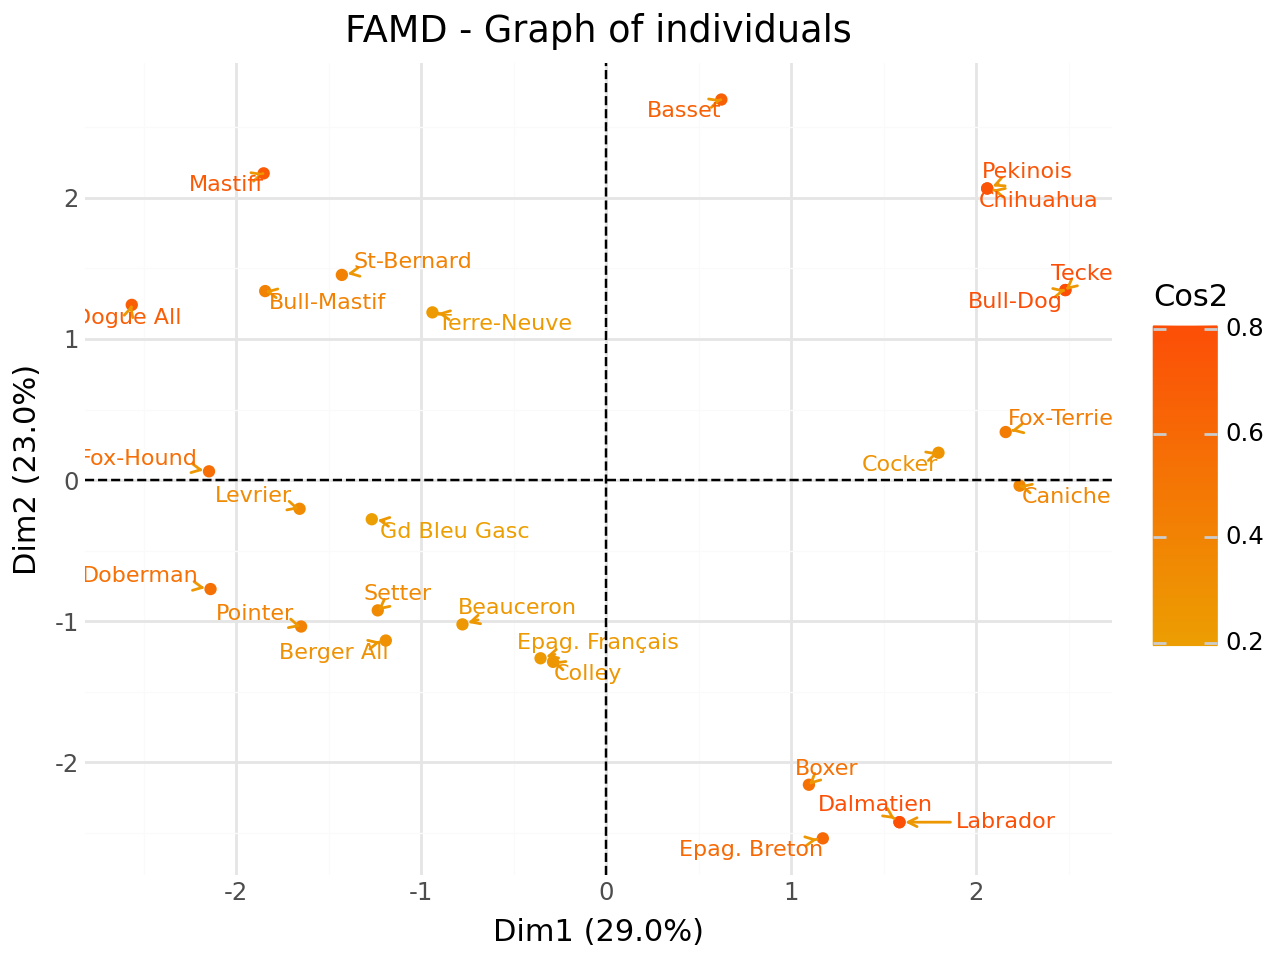

None


In [22]:
# graph of individuals - color by cosinus
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind="cos2",
    repel=True,
    ind_sup=False
)
print(p.show())

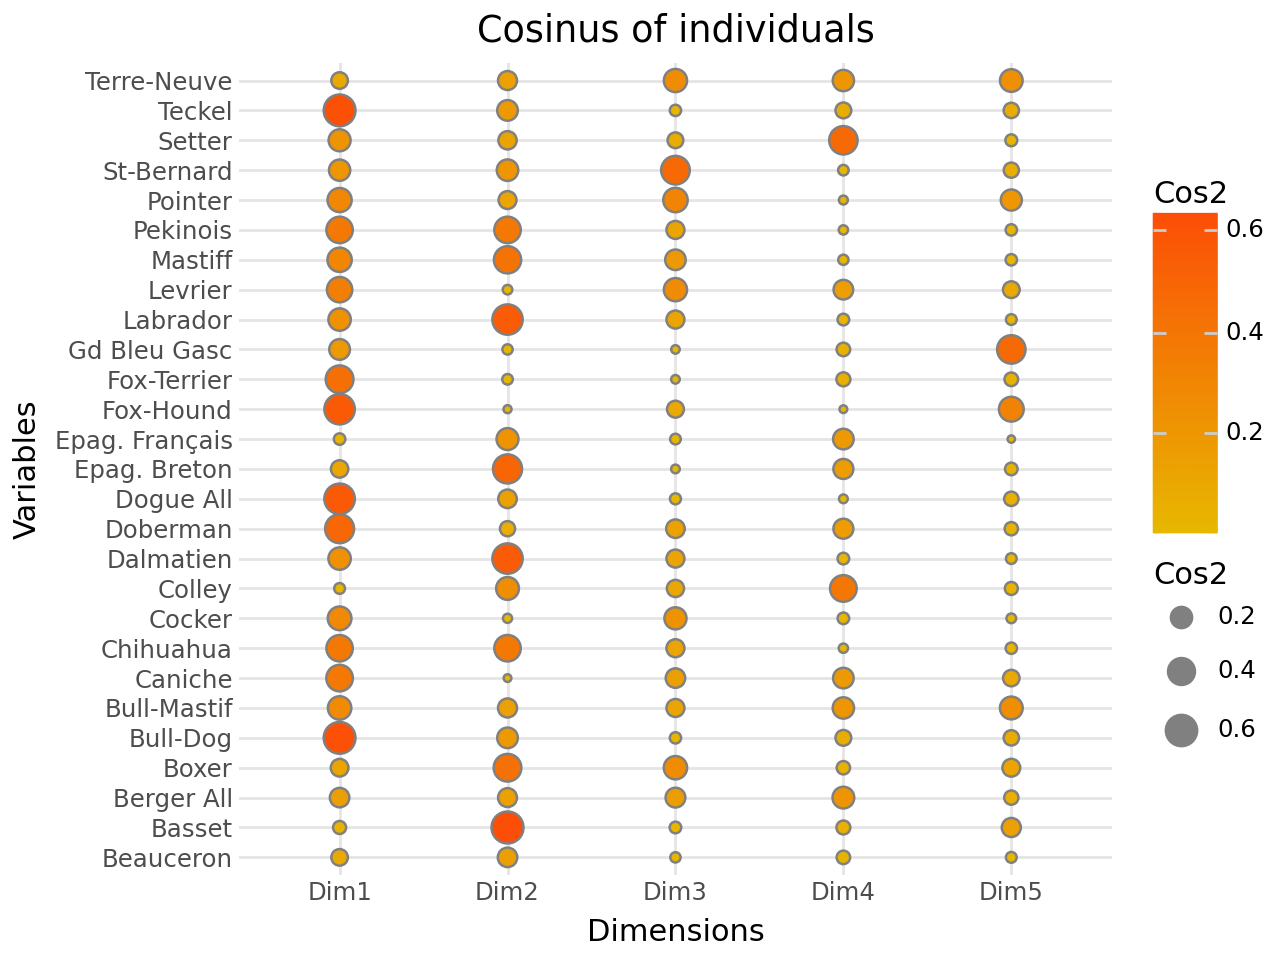

None


In [23]:
# graph of cosinus
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

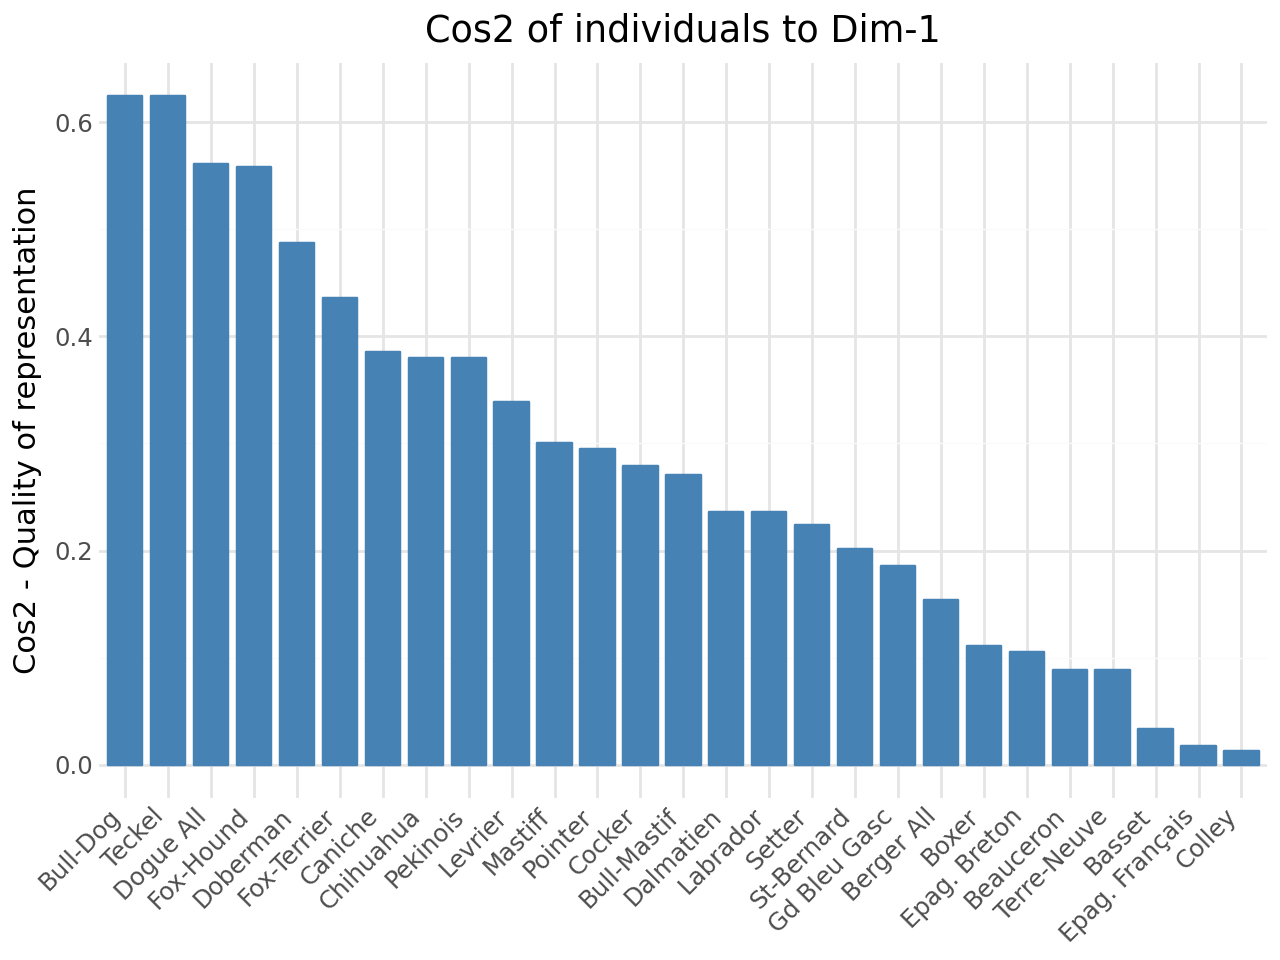

None


In [24]:
# cosinus of individuals to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals additionals informations

In [25]:
# individuals additionals informations
ind.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
Beauceron,0.037037,6.810989,0.252259,2.522589
Basset,0.037037,11.460989,0.424481,4.244811
Berger All,0.037037,9.234066,0.342002,3.420024
Boxer,0.037037,10.785989,0.399481,3.994811
Bull-Dog,0.037037,9.866209,0.365415,3.654151
Bull-Mastif,0.037037,12.553846,0.464957,4.649573
Caniche,0.037037,12.964286,0.480159,4.801587
Chihuahua,0.037037,11.164286,0.413492,4.134921
Cocker,0.037037,11.557418,0.428053,4.280525
Colley,0.037037,6.662637,0.246764,2.467643


## Levels informations

In [26]:
# levels informations
levels = clf.levels_
levels._fields

('coord', 'cos2', 'dist2', 'contrib', 'vtest')

### Levels coordinates

In [27]:
# levels coordinates
levels.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille+,1.446759,-1.871413,1.143103,0.332963,-0.294260
Taille++,-1.422259,-0.031266,-0.057622,-0.165503,0.106929
Taille-,2.014298,1.403722,-0.693027,0.116818,-0.018947
Poids+,-0.519156,-1.244159,-0.260191,-0.115083,-0.180521
Poids++,-1.725620,1.479696,1.374348,0.065731,0.583241
Poids-,1.987036,1.252468,-0.403633,0.160313,-0.048614
Veloc+,1.026203,-1.348899,0.400867,0.359979,-0.352151
Veloc++,-1.516475,-0.564944,-0.858507,-0.233199,-0.009575
Veloc-,0.543865,1.587569,0.451963,-0.078104,0.290338
Intell+,0.628013,-0.433779,0.554875,-0.586762,0.138812


The levels coordinates obtained with `FAMD` differs from that obtained with `MCA` from a factor $\sqrt{\lambda_{\alpha}}$. As stated above, the levels coordinates obtained with `MCA` are quasi-barycenters whereas they are barycenters with `FAMD`.

In [28]:
# barycenters coordinates
from numpy import sqrt
levels.coord*sqrt(eig["Eigenvalue"][:clf.call_.ncp].to_numpy()/J)

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille+,1.004020,-1.160785,0.525024,0.132163,-0.114017
Taille++,-0.987017,-0.019393,-0.026466,-0.065693,0.041432
Taille-,1.397880,0.870689,-0.318305,0.046369,-0.007342
Poids+,-0.360283,-0.771717,-0.119505,-0.045680,-0.069946
Poids++,-1.197543,0.917814,0.631234,0.026091,0.225988
Poids-,1.378960,0.776871,-0.185387,0.063633,-0.018837
Veloc+,0.712163,-0.836684,0.184117,0.142887,-0.136448
Veloc++,-1.052401,-0.350419,-0.394310,-0.092564,-0.003710
Veloc-,0.377430,0.984724,0.207585,-0.031002,0.112497
Intell+,0.435827,-0.269061,0.254852,-0.232904,0.053786


10 [-0.7124248  -0.83610328]
18 [ 0.48874987 -0.60879256]
7 [-0.87092847 -0.14131847]
21 [0.64303769 0.23478657]


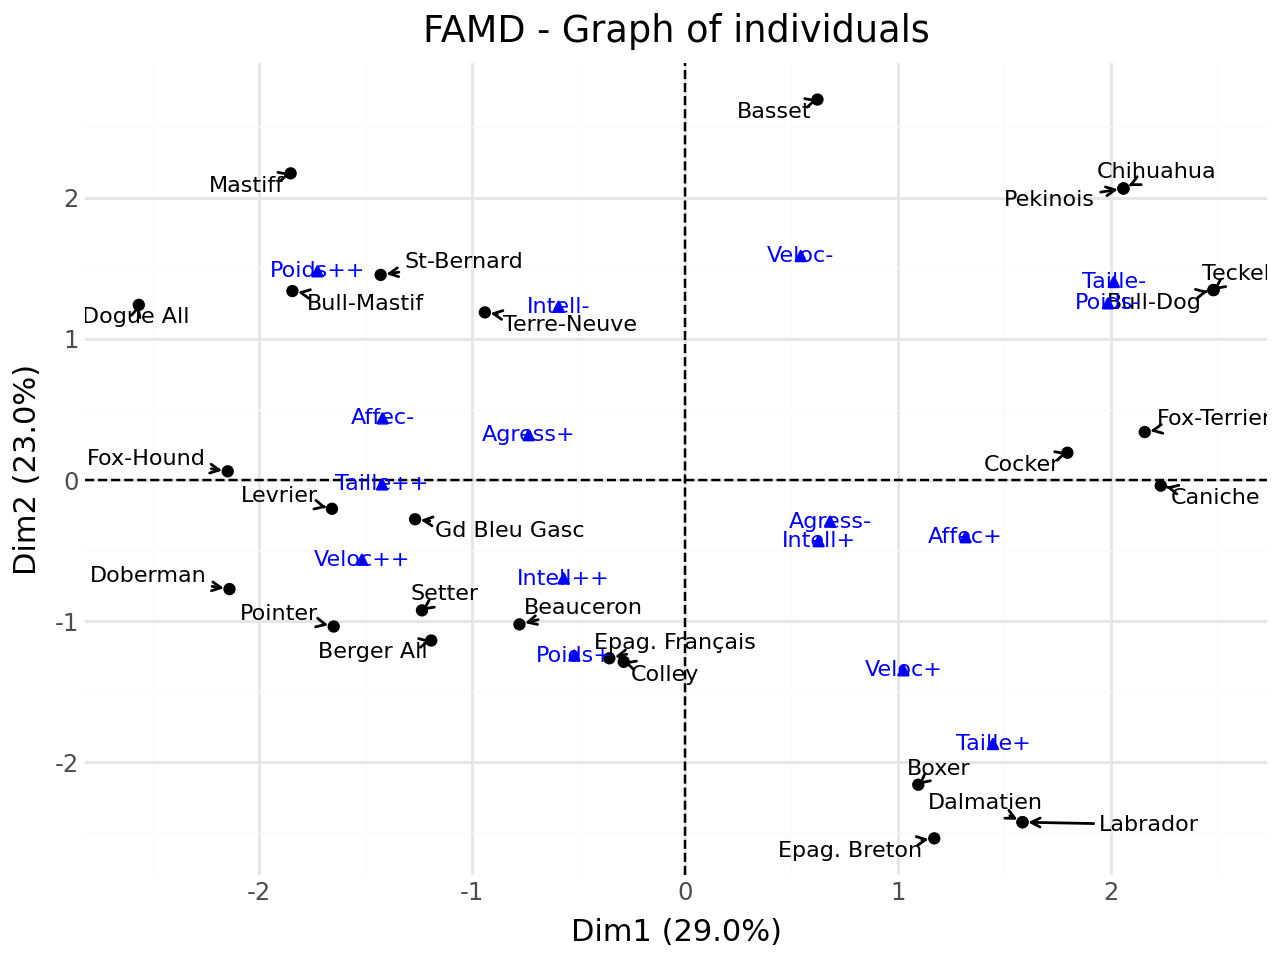

None


In [29]:
# graph of individuals with levels
from scientisttools import add_scatter
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = False
)
# add levels coordinates
p = add_scatter(
    p = p,
    data = levels.coord,
    color = "blue"
)
print(p.show())

### Levels vtest

In [30]:
# levels vtest
levels.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille+,2.068878,-2.994141,2.469882,0.832464,-0.753665
Taille++,-4.769783,-0.117315,-0.291984,-0.970413,0.642278
Taille-,3.574562,2.787045,-1.858237,0.362445,-0.060222
Poids+,-1.616053,-4.333083,-1.223777,-0.626323,-1.006452
Poids++,-2.467651,2.367418,2.969528,0.164338,1.493809
Poids-,3.867577,2.727493,-1.187057,0.545548,-0.169475
Veloc+,1.997406,-2.937492,1.178924,1.225017,-1.227638
Veloc++,-3.216512,-1.340661,-2.751351,-0.864785,-0.036375
Veloc-,1.251214,4.086363,1.571069,-0.314157,1.196337
Intell+,1.815270,-1.402831,2.423369,-2.965280,0.718636


### Levels contributions

In [31]:
# levels contributions
levels.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille+,4.642073,12.170670,15.104237,2.297396,1.976132
Taille++,13.458546,0.010191,0.115139,1.702852,0.782824
Taille-,12.597815,9.586617,7.772416,0.395909,0.011470
Poids+,1.673686,15.062072,2.191147,0.768462,2.082406
Poids++,6.604042,7.608867,21.833395,0.089533,7.763356
Poids-,14.010416,8.722246,3.013148,0.852122,0.086298
Veloc+,3.736854,10.117058,2.972003,4.296552,4.528256
Veloc++,9.180417,1.996447,15.335161,2.028481,0.003766
Veloc-,1.311993,17.517423,4.722403,0.252828,3.847622
Intell+,2.274208,1.700144,9.253181,18.549900,1.143359


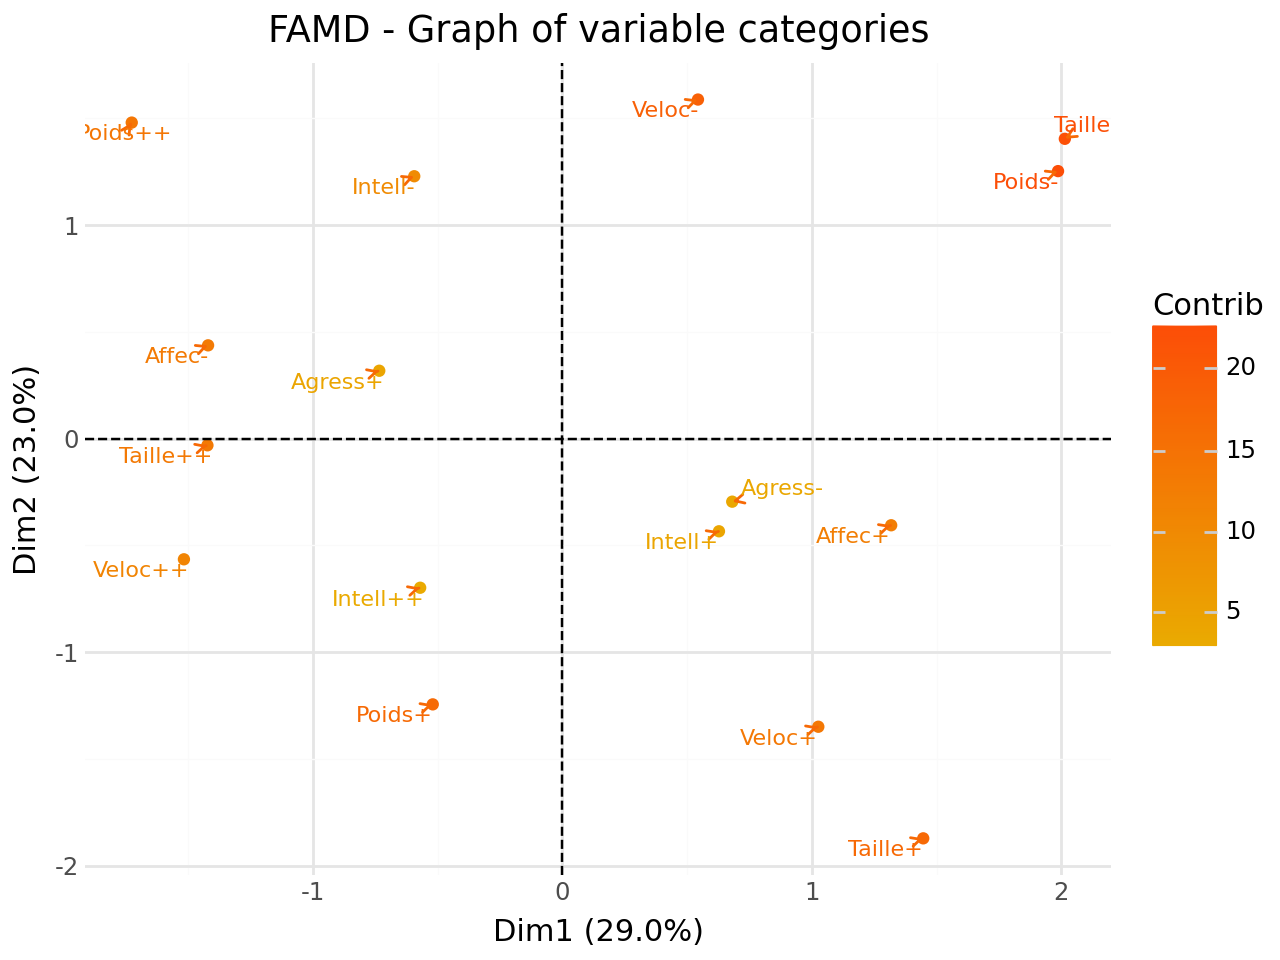

None


In [32]:
# graph of variable categories  - color by contributions
p = fviz_mix(
    obj=clf,
    choice="levels",
    col_var = "contrib",
    repel=True,
    quali_sup=False
)
print(p.show())

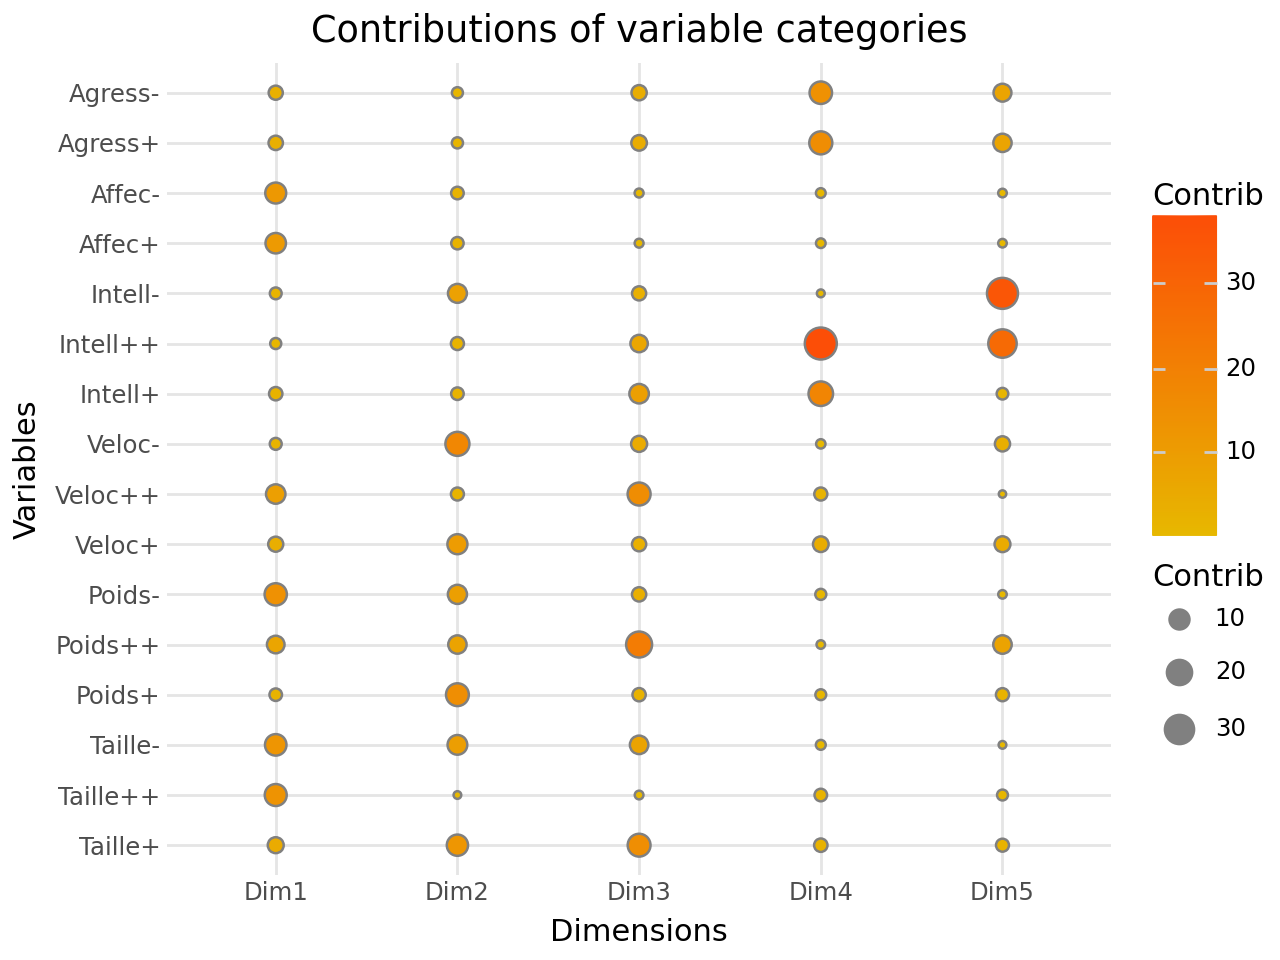

None


In [33]:
# graph of contributions for variable categories
p = fviz_corrplot(
    X=levels.contrib,
    legend_title="Contrib",
    title="Contributions of variable categories"
)
print(p.show())

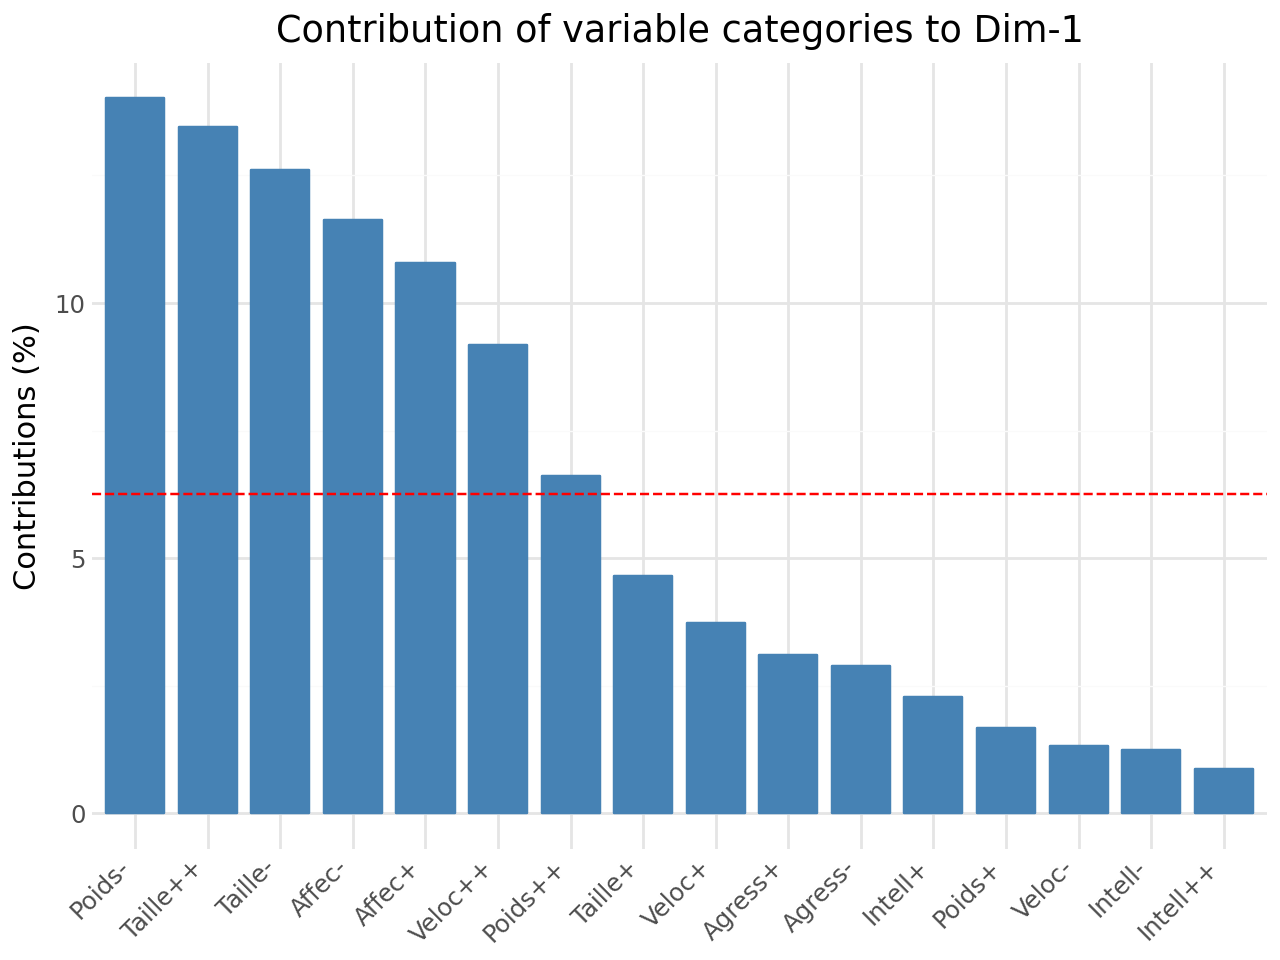

None


In [34]:
# contributions of levels to axis 1
p = fviz_contrib(
    obj=clf,
    choice="levels"
)
print(p.show())

### Levels cos2

In [35]:
# levels cos2
levels.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille+,0.279019,0.466854,0.174186,0.014779,0.011543
Taille++,0.972936,0.000470,0.001597,0.013175,0.005499
Taille-,0.615576,0.298948,0.072868,0.002070,0.000054
Poids+,0.138830,0.797334,0.034872,0.006822,0.016786
Poids++,0.392658,0.288715,0.249068,0.000570,0.044856
Poids-,0.685379,0.272303,0.028281,0.004461,0.000410
Veloc+,0.278621,0.481401,0.042516,0.034285,0.032810
Veloc++,0.629091,0.087308,0.201619,0.014876,0.000025
Veloc-,0.092658,0.789526,0.063989,0.001911,0.026406
Intell+,0.281612,0.134354,0.219839,0.245832,0.013758


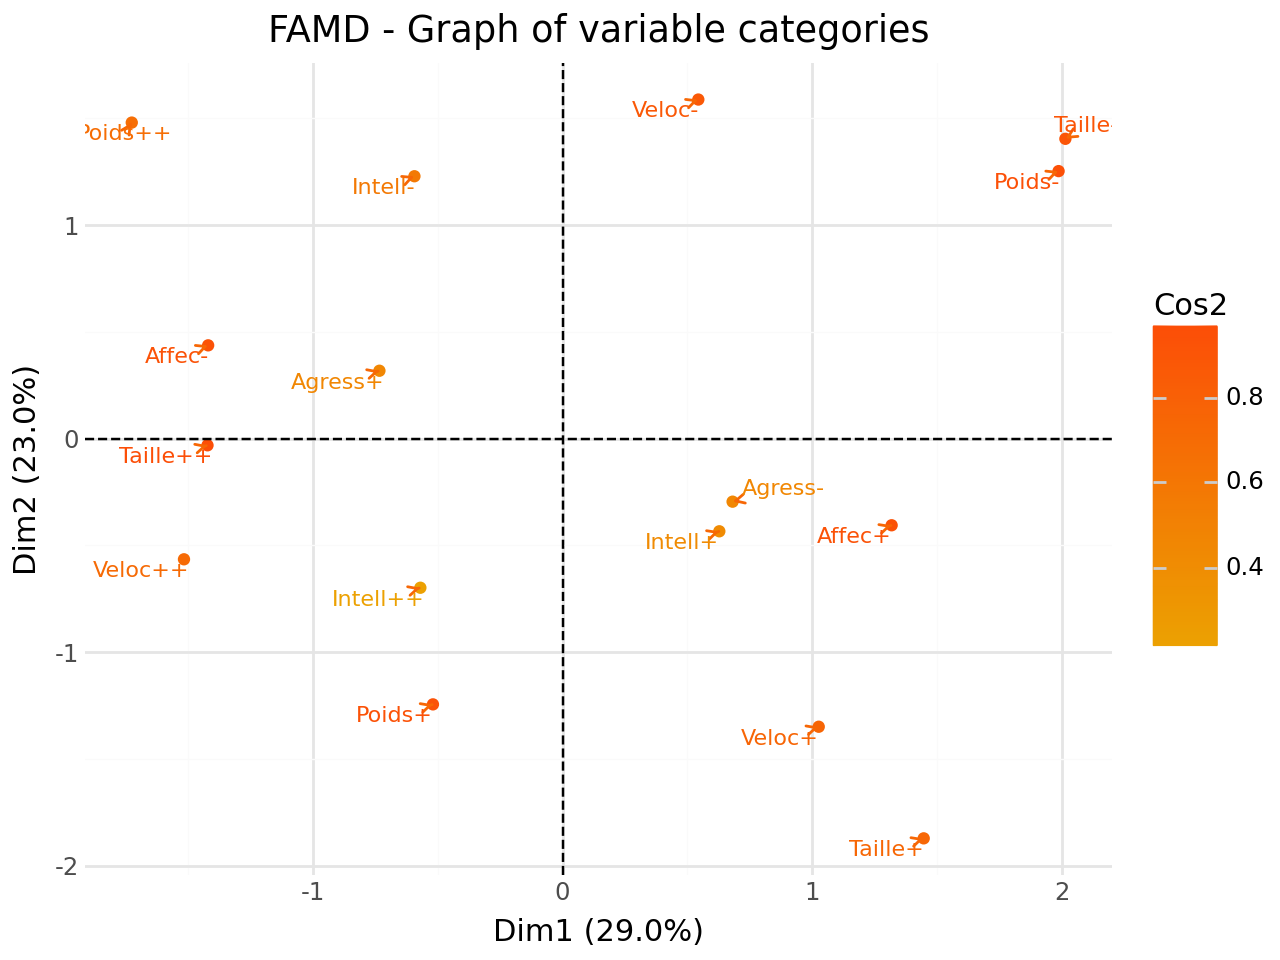

None


In [36]:
# graph of variable categories - color by cosinus
p = fviz_mix(
    obj=clf,
    choice="levels",
    col_var = "cos2",
    repel=True,
    quali_sup=False
)
print(p.show())

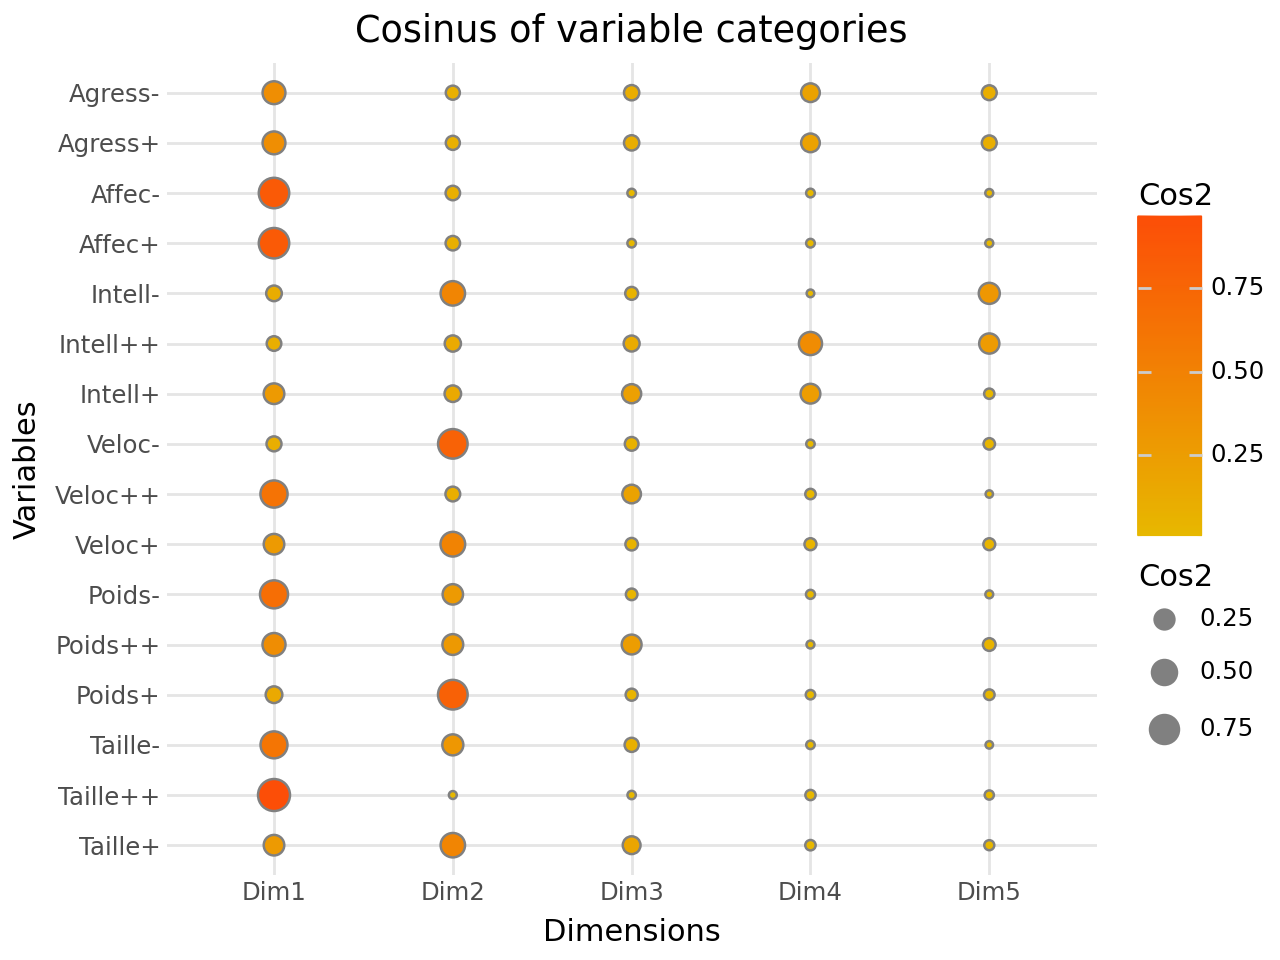

None


In [37]:
# graph of cosinus for variable categories
p = fviz_corrplot(
    X=levels.cos2,
    legend_title="Cos2",
    title="Cosinus of variable categories"
)
print(p.show())

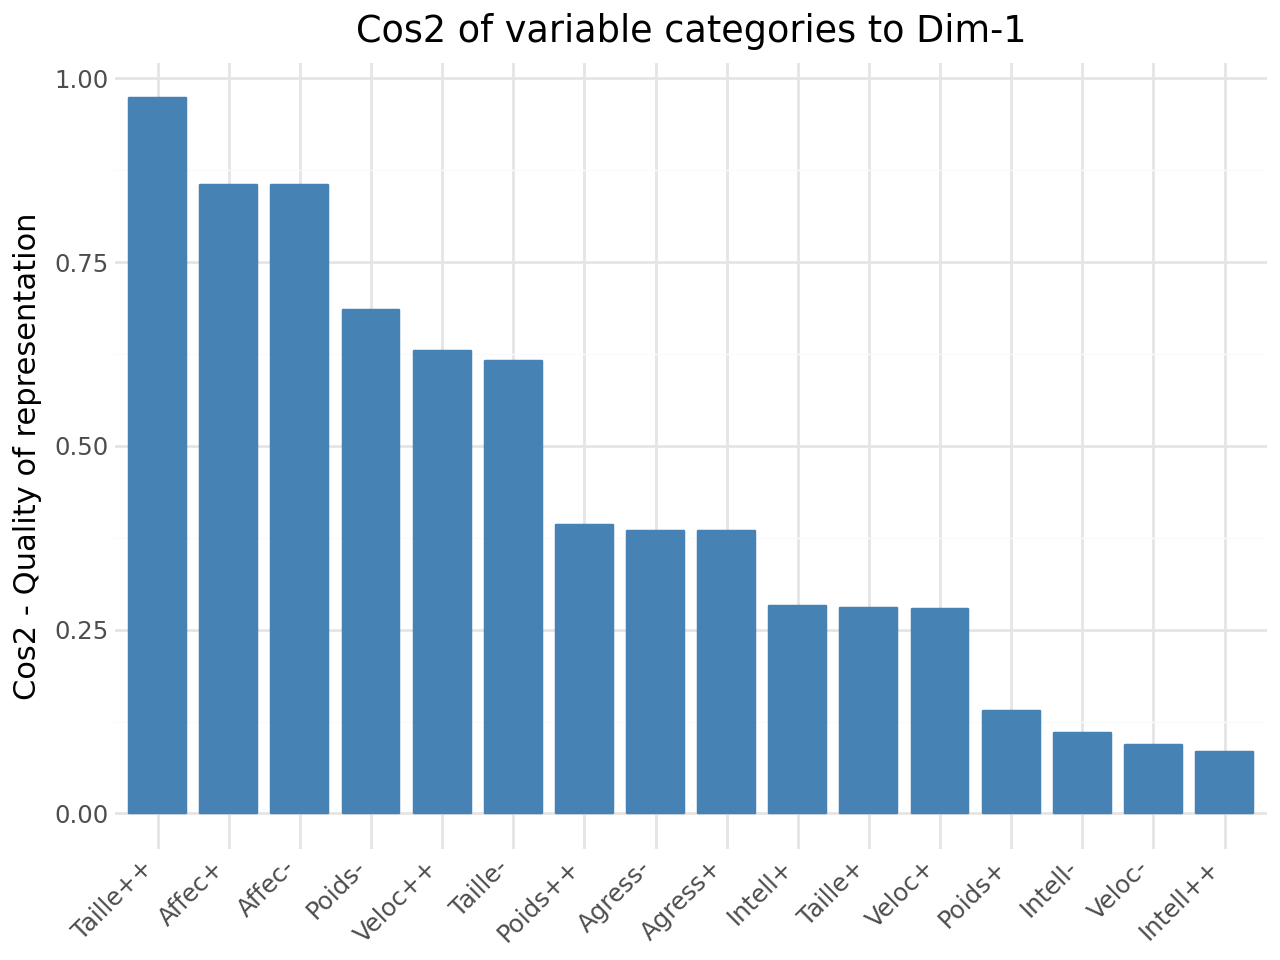

None


In [38]:
# cosinus of variable categories to axis 1
p = fviz_cos2(
    obj=clf,
    choice="levels"
)
print(p.show())

### Levels dist2

In [39]:
# levels dist2
levels.dist2.to_frame()

,Sq. Dist.
Taille+,7.501681
Taille++,2.079088
Taille-,6.591220
Poids+,1.941384
Poids++,7.583604
Poids-,5.760770
Veloc+,3.779657
Veloc++,3.655586
Veloc-,3.192264
Intell+,1.400509


## Qualitative variables informations

In [40]:
# qualitative variables informations
quali_var = get_mix(clf,"quali_var")
quali_var._fields

('coord', 'contrib')

### Qualitative variables coordinates

In [41]:
# qualitative variables coordinates
quali_var.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille,0.887073,0.502486,0.291013,0.041558,0.024956
Poids,0.644046,0.724688,0.342223,0.016166,0.089468
Velocite,0.411174,0.684007,0.291491,0.062182,0.075484
Intelligence,0.126764,0.279870,0.233710,0.536922,0.578931
Affection,0.647656,0.076736,0.003981,0.006421,0.001751
Agressivite,0.172924,0.040637,0.103308,0.282075,0.130207


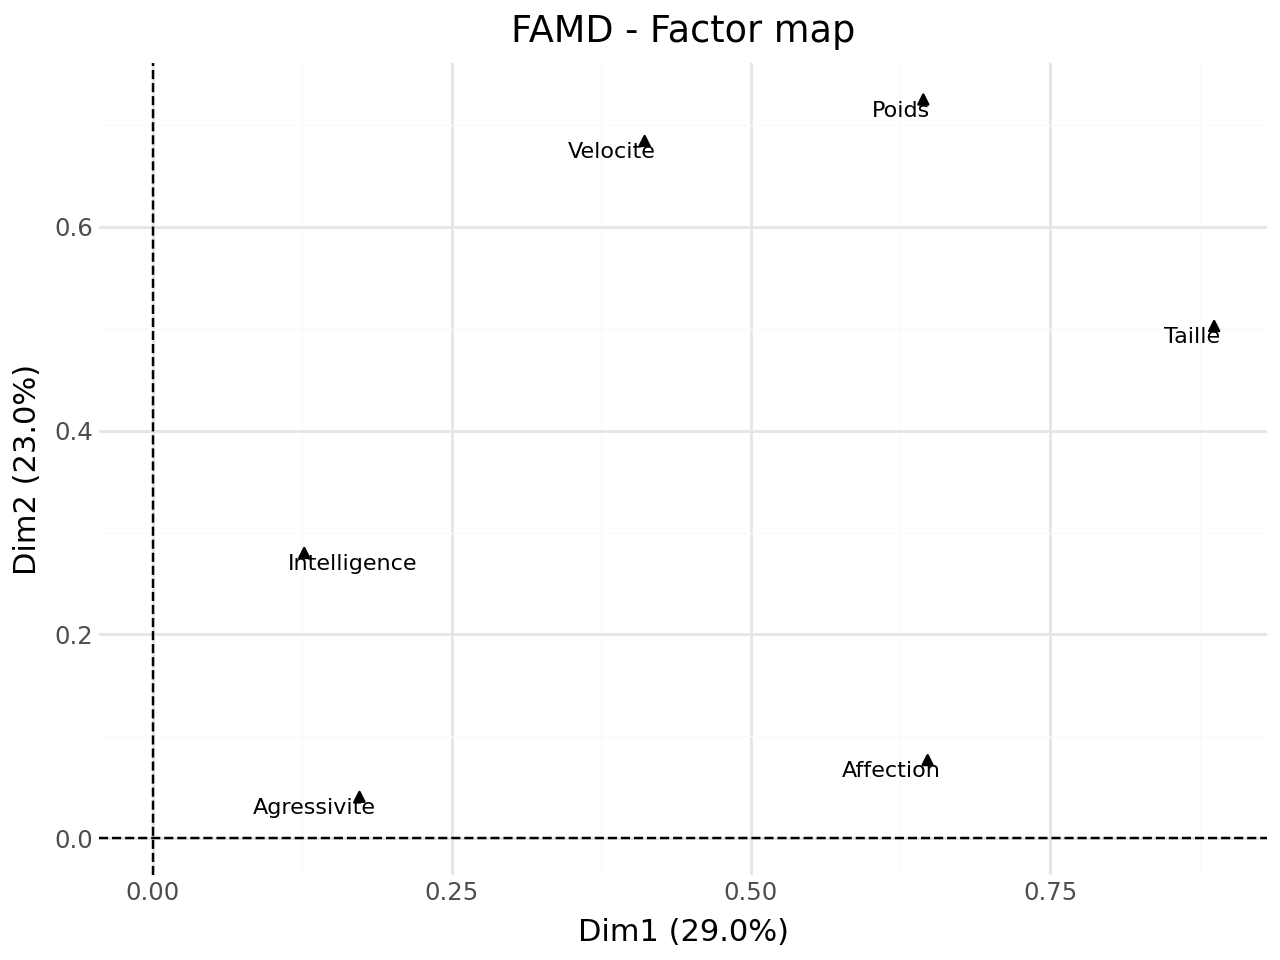

None


In [42]:
# graph of variables
from plotnine import ggplot
from scientisttools import set_axis
p = add_scatter(
    p = ggplot(),
    data=quali_var.coord,
    color="black",
    repel = True
)
p = set_axis(
    p = p,
    obj=clf
)
print(p.show())

### Qualitative variables contributions

In [43]:
# qualitative variables contributions
quali_var.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Taille,30.698434,21.767479,22.991793,4.396158,2.770426
Poids,22.288144,31.393185,27.037690,1.710116,9.932061
Velocite,14.229264,29.630928,23.029566,6.577861,8.379644
Intelligence,4.386832,12.123861,18.464515,56.797624,64.268793
Affection,22.413052,3.324175,0.314491,0.679230,0.194374
Agressivite,5.984273,1.760373,8.161945,29.839010,14.454702


## Supplementary individuals informations

In [44]:
# supplementary individuals informations
ind_sup = clf.ind_sup_
ind_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary individuals coordinates

In [45]:
# supplementary individuals coordinates
ind_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Medor,0.434258,0.444076,0.762733,2.232138,0.621588
Djeck,0.175029,-0.448339,1.466051,-0.792405,0.938192
Taico,-0.002151,-0.516033,-1.722183,1.713047,0.536080
Rocky,1.162741,-1.705363,0.372484,0.189248,-1.599720
Boudog,0.332096,1.044901,-0.751644,-0.092881,-0.371830
Wisky,0.088716,1.012206,2.276013,1.010349,-0.799509


10 [ 0.86749471 -0.22861065]
18 [-0.96922585  0.58788894]
7 [0.33639615 0.54916882]
21 [-0.52244617 -0.48292492]


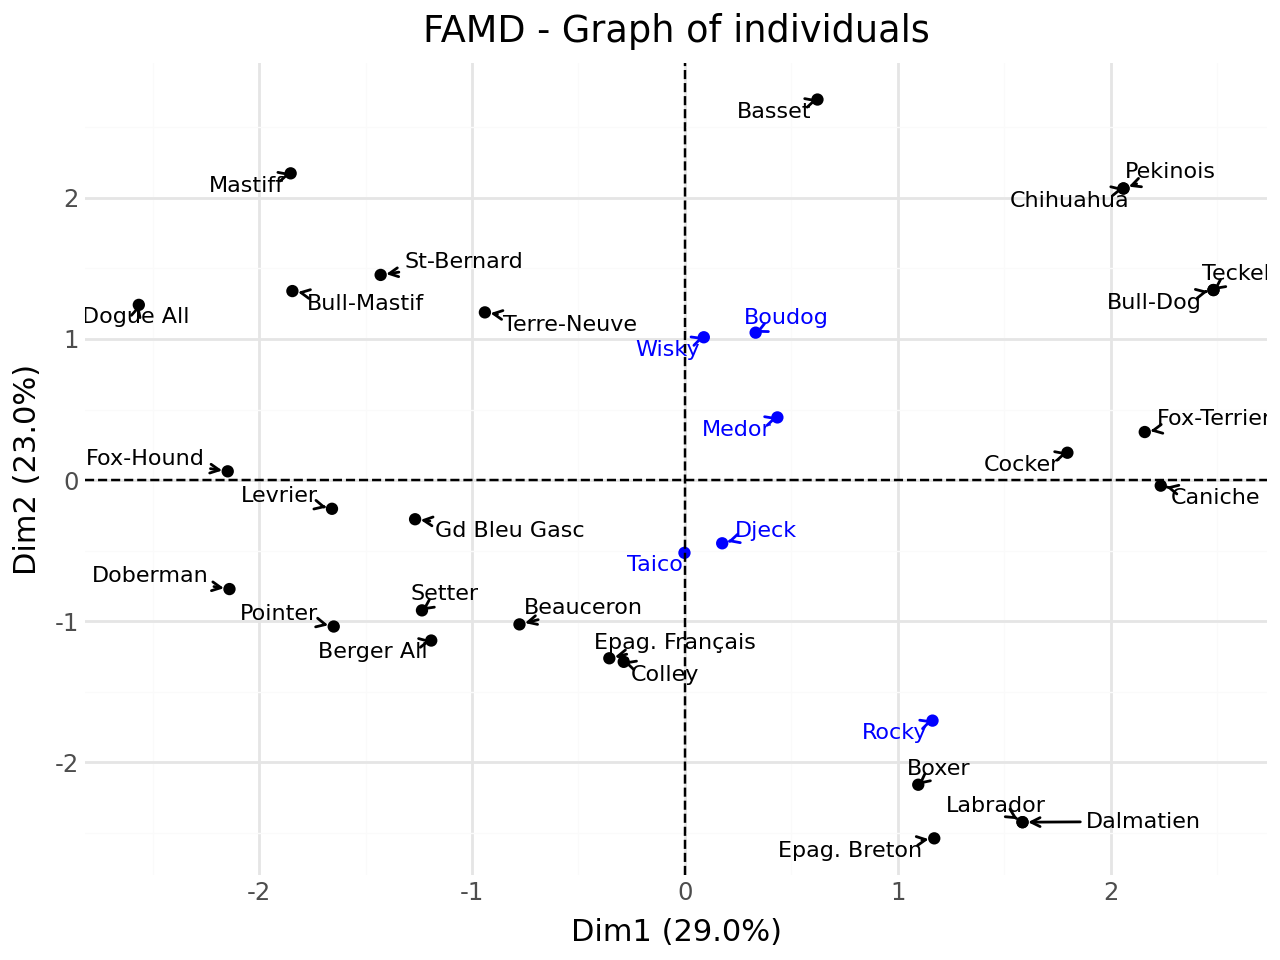

None


In [46]:
# graph of individuals
from scientisttools import fviz_mix
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = True
)
print(p.show())

### Supplementary individuals cos2

In [47]:
# individuals cos2
ind_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Medor,1.334717e-02,0.013958,0.041175,0.352643,0.027346
Djeck,2.915118e-03,0.019127,0.204519,0.059749,0.083757
Taico,4.099356e-07,0.023584,0.262675,0.259895,0.025452
Rocky,1.132707e-01,0.243661,0.011624,0.003001,0.214407
Boudog,1.054083e-02,0.104351,0.053997,0.000825,0.013214
Wisky,5.289124e-04,0.068853,0.348123,0.068600,0.042956


### Supplementary individuals dist2

In [48]:
# supplementary individuals dist2
ind_sup.dist2.to_frame()

,Sq. Dist.
Medor,14.128846
Djeck,10.509066
Taico,11.291209
Rocky,11.935714
Boudog,10.462912
Wisky,14.880495


## Supplementary quantitative variables informations

In [49]:
# supplementary quantitative variables
quanti_var_sup = clf.quanti_var_sup_
quanti_var_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary quantitative variables coordinates

In [50]:
# supplementary quantitative variables coordinates
quanti_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Cote,-0.042141,0.601291,0.258801,0.342585,-0.030073


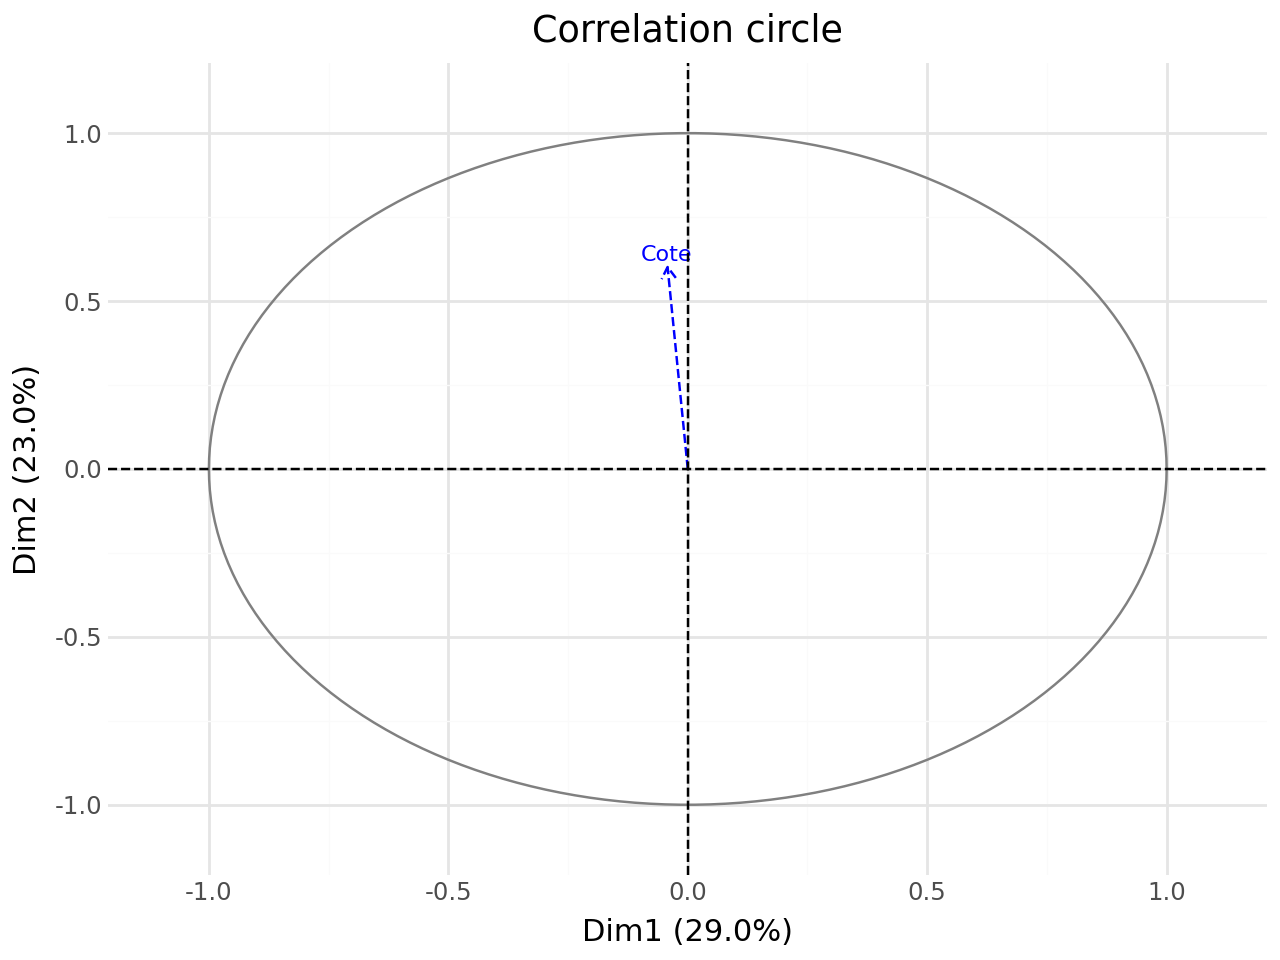

None


In [51]:
# graph of variables - correlation circle
from scientisttools import add_arrow, fviz_circle, set_axis
p = add_arrow(
    p=ggplot(),
    data=quanti_var_sup.coord,
    repel=True
)
p = fviz_circle(p=p)
p = set_axis(
    p = p,
    obj=clf,
    x_lim = (-1.1,1.1),
    y_lim = (-1.1,1.1),
    title="Correlation circle"
)
print(p.show())

### Supplementary quantitative variables cos2

In [52]:
# supplementary quantitative variables cos2
quanti_var_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Cote,0.001776,0.361551,0.066978,0.117364,0.000904


## Supplementary levels informations

In [53]:
# supplementary levels informations
levels_sup = clf.levels_sup_
levels_sup._fields

('coord', 'cos2', 'dist2', 'vtest')

### Supplementary levels coordinates

In [54]:
# supplementary levels coordinates
levels_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
chasse,-0.548030,-0.657016,-0.392358,-0.178846,-0.420396
compagnie,1.766768,0.144825,-0.076386,-0.086498,-0.010576
utilite,-1.591927,0.558111,0.536885,0.309324,0.486165


10 [-0.73270986 -0.03561254]
18 [ 0.5234114  -0.95138121]
7 [-0.94650024  0.06063214]
21 [-0.12427021 -0.62756593]


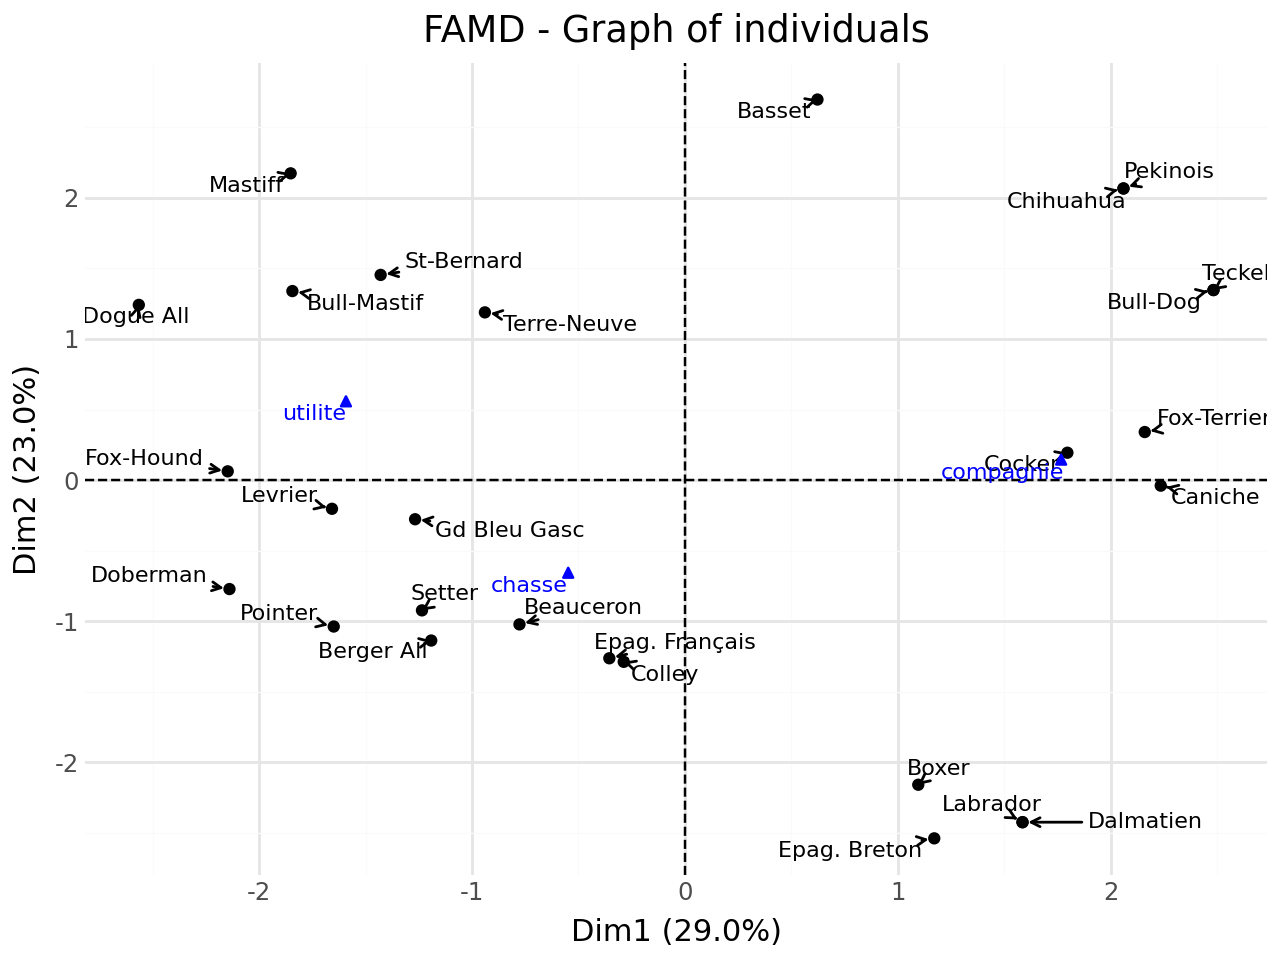

None


In [55]:
# graph of individuals with supplementary levels
from scientisttools import add_scatter
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = False
)
# add levels coordinates
p = add_scatter(
    p = p,
    data = levels_sup.coord,
    color = "blue"
)
print(p.show())

### Supplementary levels vtest

In [56]:
# supplementary levels vtest
levels_sup.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
chasse,-1.162396,-1.559156,-1.257432,-0.663224,-1.597044
compagnie,4.064622,0.372776,-0.265527,-0.347919,-0.043577
utilite,-3.098535,1.215397,1.578945,1.052636,1.694827


### Supplementary levels cos2

In [57]:
# supplementary levels cos2
levels_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
chasse,0.196097,0.281847,0.100514,0.020884,0.115393
compagnie,0.968474,0.006508,0.001810,0.002321,0.000035
utilite,0.694219,0.085328,0.078961,0.026211,0.064747


### Supplementary levels dist2

In [58]:
# supplementary levels dist2
levels_sup.dist2.to_frame()

,Sq. Dist.
chasse,1.531573
compagnie,3.223080
utilite,3.650481


## Supplementary qualitative variables informations

In [59]:
# supplementary qualitative variables informations
quali_var_sup = clf.quali_var_sup_
quali_var_sup._fields

('coord',)

### Supplementary qualitative variables coordinates

In [60]:
# supplementary qualitative variables coordinates
quali_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Fonction,0.694584,0.105679,0.109725,0.0442,0.143189


## Others functions

### Ellipses - `fviz_ellipses`

3 [-0.75912969 -0.32687217]
6 [ 0.51999612 -0.02886322]
3 [-0.597129    0.43132599]
5 [ 0.74669125 -0.36684314]


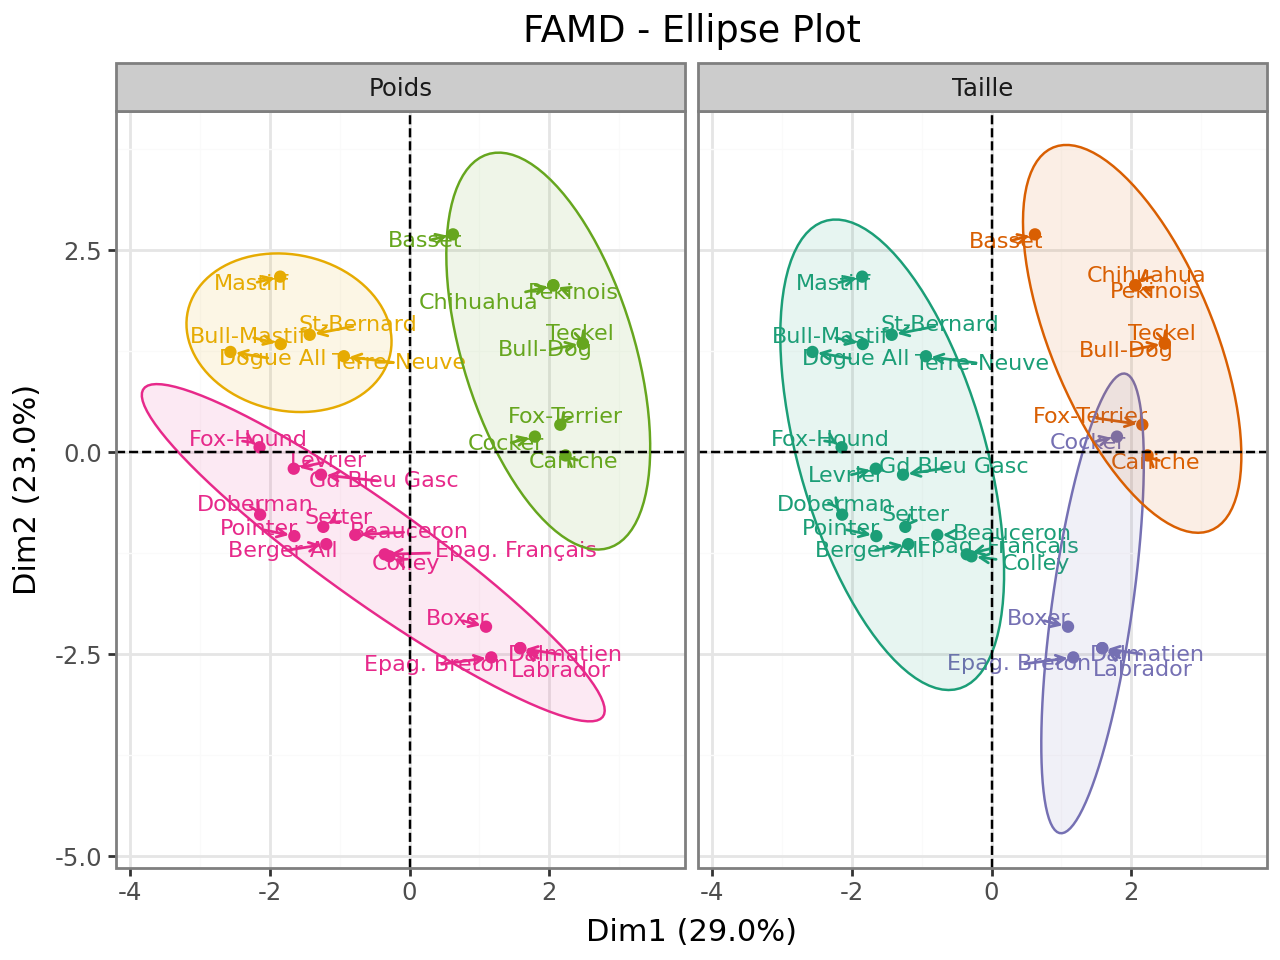

None


In [61]:
# ellipses
from scientisttools import fviz_ellipses
p = fviz_ellipses(
    obj=clf,
    habillage=["Taille","Poids"],
    repel=True,
    add_ellipses=True
)
print(p.show())

### Summaries - `summary`

In [62]:
# summary
from scientisttools import summary
summary(clf)

                     Factor Analysis of Mixed Data - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      2.8896      0.5812         28.8964         28.8964
Dim2      2.3084      1.0427         23.0842         51.9806
Dim3      1.2657      0.3204         12.6572         64.6379

Individuals (the 10 first):
               Dim1    cos2     ctr    Dim2    cos2      ctr    Dim3    cos2  \
Beauceron   -0.7770  0.0886  0.7738 -1.0232  0.1537   1.6796 -0.2485  0.0091   
Basset       0.6224  0.0338  0.4966  2.6974  0.6349  11.6742 -0.4671  0.0190   
Berger All  -1.1914  0.1537  1.8194 -1.1377  0.1402   2.0766 -1.2202  0.1612   
Boxer        1.0958  0.1113  1.5391 -2.1599  0.4325   7.4850  1.6951  0.2664   
Bull-Dog     2.4822  0.6245  7.8971  1.3469  0.1839   2.9108 -0.4003  0.0162   
Bull-Mastif -1.8434  0.2707  4.3556  1.3397  0.1430   2.8794  1.2188  0.1183   
Caniche      2.2347  0.3852  6.4006 -0.0397  0.0001   0.00

In [63]:
# formatting text to markdown
summary(clf,to_markdown=True)

                     Factor Analysis of Mixed Data - Results                     

Importance of components:
        Eigenvalue    Difference    Proportion (%)    Cumulative (%)
----  ------------  ------------  ----------------  ----------------
Dim1        2.8896        0.5812           28.8964           28.8964
Dim2        2.3084        1.0427           23.0842           51.9806
Dim3        1.2657        0.3204           12.6572           64.6379

Individuals (the 10 first):
                Dim1    cos2     ctr     Dim2    cos2      ctr     Dim3    cos2     ctr
-----------  -------  ------  ------  -------  ------  -------  -------  ------  ------
Beauceron    -0.777   0.0886  0.7738  -1.0232  0.1537   1.6796  -0.2485  0.0091  0.1808
Basset        0.6224  0.0338  0.4966   2.6974  0.6349  11.6742  -0.4671  0.019   0.6385
Berger All   -1.1914  0.1537  1.8194  -1.1377  0.1402   2.0766  -1.2202  0.1612  4.3565
Boxer         1.0958  0.1113  1.5391  -2.1599  0.4325   7.485    1.6951  0.26

### Dimension description - `dimdesc`

In [64]:
# dimension description
from scientisttools import dimdesc
dim_desc = dimdesc(clf,axis=[0,1])
dim_desc.keys()

dict_keys(['Dim1', 'Dim2'])

### `Dim1` dimension

In [65]:
# Dim1 dimension
dim_desc["Dim1"]._fields

('call', 'quali', 'category')

#### Description of Dim1 by levels

In [66]:
# description of Dim1 by levels
dim_desc["Dim1"].category

,Estimate,pvalue
Taille=Taille+,1.775568,3.574570e-02
Taille=Taille++,-3.200082,8.616471e-13
Taille=Taille-,2.719303,4.642696e-05
Poids=Poids++,-2.117806,1.053636e-02
Poids=Poids-,2.823682,4.553328e-06
Velocite=Veloc+,1.458288,4.330936e-02
Velocite=Veloc++,-2.274712,4.193918e-04
Affection=Affec+,2.737927,4.184726e-07
Affection=Affec-,-2.737927,4.184726e-07
Agressivite=Agress+,-1.414741,3.098130e-02


#### Description of Dim1 by qualitative variables

In [67]:
# description of Dim1 by qualitative variables
dim_desc["Dim1"].quali

,R2,pvalue
Taille,0.887073,4.300901e-12
Fonction,0.694584,6.587193e-07
Affection,0.647656,4.184726e-07
Poids,0.644046,4.137327e-06
Velocite,0.411174,1.737173e-03
Agressivite,0.172924,3.098130e-02
